# IOV Accelerometer Signal Analysis
## Part 2: Signal Characterization

Building on the clean dataset established in Part 1.
Each task has its own code block. All values are computed from data.

In [2]:
# ------------------------------------------------------------
# Dependencies installing 
# ------------------------------------------------------------

import subprocess, sys

PACKAGES = ['pandas', 'numpy', 'matplotlib', 'scipy']

for pkg in PACKAGES:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )
    print(f'  {pkg:<15} installed')

print()
print('All dependencies ready.')

  pandas          installed
  numpy           installed
  matplotlib      installed
  scipy           installed

All dependencies ready.


In [3]:
# ------------------------------------------------------------
# Imports, plot style, and data reload
# Side note: Reproduces the Part 1 cleaning pipeline so this notebook
# runs independently without a shared kernel session.
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import time

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.color': '#d0d0d0',
    'grid.linestyle': ':',
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
})

AXIS_COLORS = {'acc_x': '#1f77b4', 'acc_y': '#2ca02c', 'acc_z': '#d62728'}
AXIS_LABELS = {'acc_x': 'X Axis', 'acc_y': 'Y Axis', 'acc_z': 'Z Axis'}

FILE_PATH = Path('Raw_Data/iov.log_2025_10_26')

def _detect_header(fp):
    with open(fp, 'r') as fh:
        for i, line in enumerate(fh):
            parts = line.strip().split(',')
            if len(parts) == 4:
                try:
                    [float(p) for p in parts]
                    return i
                except ValueError:
                    pass
    return 0

t0           = time.perf_counter()
HEADER_LINES = _detect_header(FILE_PATH)

df = pd.read_csv(
    FILE_PATH,
    names=['acc_x', 'acc_y', 'acc_z', 'timestamp'],
    skiprows=HEADER_LINES,
    on_bad_lines='skip',
    motor='c',
    low_memory=False,
)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df = df.dropna().reset_index(drop=True)
df = df.astype({'acc_x': 'float32', 'acc_y': 'float32',
                'acc_z': 'float32', 'timestamp': 'float64'})
df.sort_values('timestamp', inplace=True, ignore_index=True)

t_start  = float(df['timestamp'].iloc[0])
t_end    = float(df['timestamp'].iloc[-1])
duration = t_end - t_start
eff_hz   = len(df) / duration

print(f'Loaded {len(df):,} rows  in {time.perf_counter() - t0:.1f}s')
print(f'Duration : {duration / 3600:.4f} h')
print(f'Rate     : {eff_hz:.3f} Hz')

Loaded 52,660,592 rows  in 20.8s
Duration : 18.2841 h
Rate     : 800.036 Hz


Envelope : 2000 bins  x  32.91 s each
Peak event : Z-axis amplitude deviation is 1.6x the recording median at 3.4300 h into the recording
Zoom     : 1.828 h  for  5 s  (4,000 samples)
PSD      : 5.0 min  |  116 segments  |  0.195 Hz resolution
Frequency range : 0 to 400.0 Hz  (Nyquist)


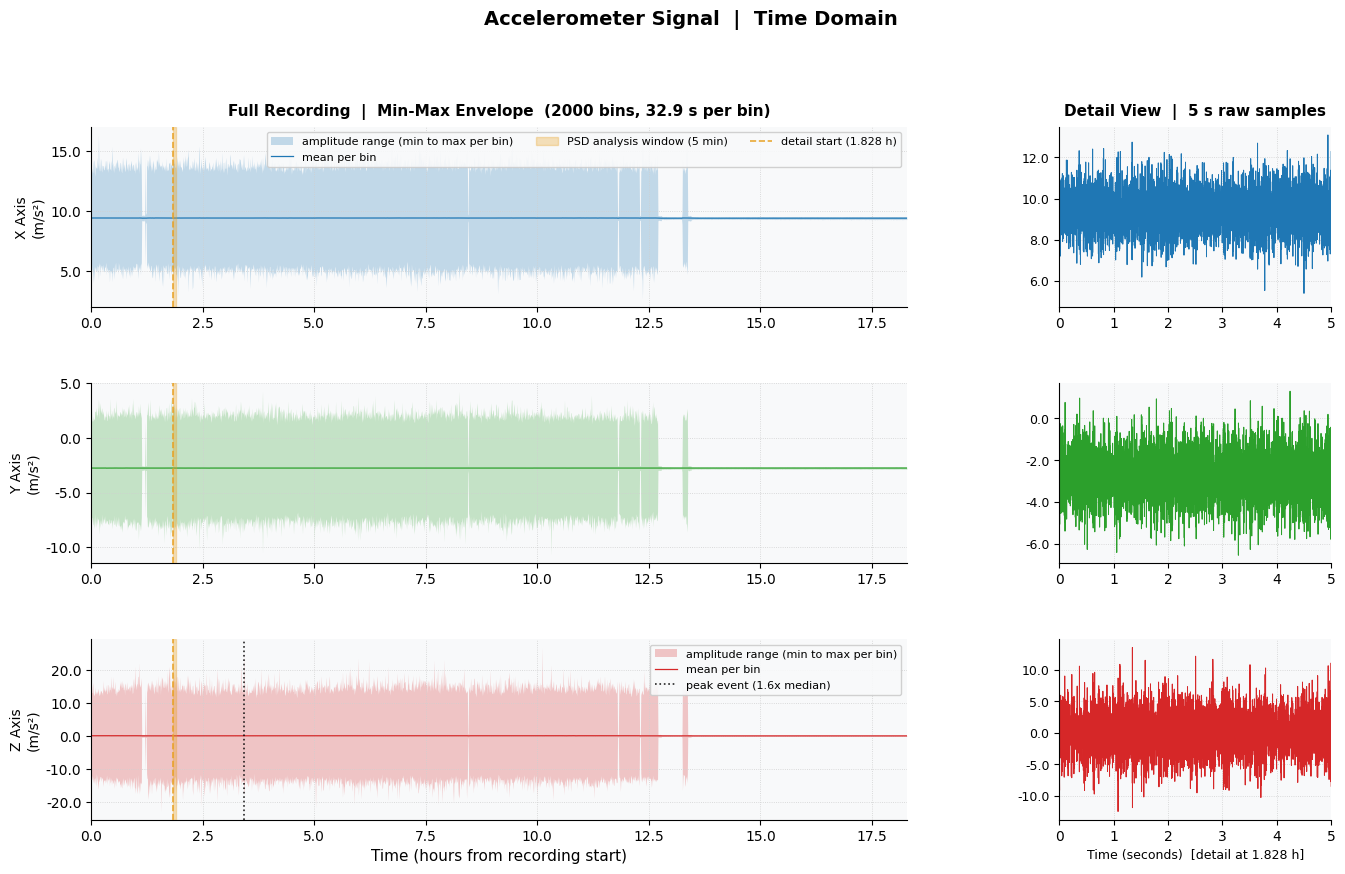

Saved: fig_time_domain.png


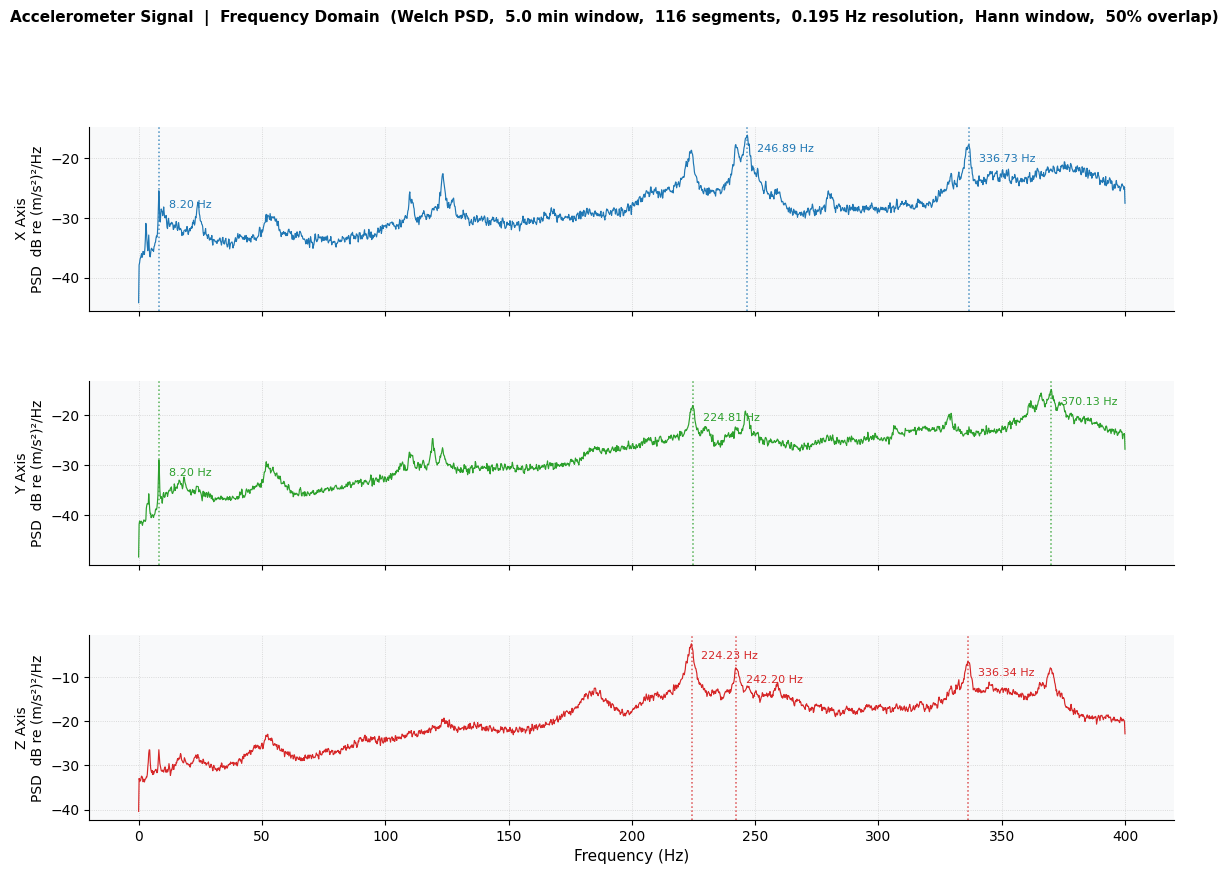

Saved: fig_frequency_domain.png


In [4]:
# ------------------------------------------------------------
# TASK 1  |  Time Domain and Frequency Domain Visualization
# ------------------------------------------------------------
# The core challenge is scale. 52 million samples cannot be
# plotted directly (Kernel previously broke for me). Two naive approaches both fail:
#
#   Plotting every point  ->  the renderer produces a solid
#   filled rectangle. Nothing is readable.
#
#   Taking every Nth point (decimation)  ->  looks plausible
#   but is wrong. Transient spikes that last only a few
#   samples get dropped entirely, making amplitude appear
#   smaller than reality. This is aliasing in the visual
#   domain, not just the signal domain.
#
# TIME DOMAIN Approach |  min-max envelope
#   Divide the full recording into N equal bins. For each
#   bin compute the true minimum and maximum. Fill between
#   them. Every amplitude extreme is preserved regardless of
#   how briefly it occurred. Overlay the per-bin mean as a
#   line to show the trend. A detail panel alongside shows
#   a short raw window so the fine signal structure is also
#   visible.
#
# FREQUENCY DOMAIN  |  Welch Power Spectral Density Approach 
#   A single FFT on a long noisy signal has very high
#   variance. Every bin fluctuates wildly. Welch's method
#   divides a representative window into overlapping
#   segments, applies a Hann window to each (tapering
#   segment edges reduces spectral leakage), computes the
#   FFT of each, and averages squared magnitudes. More
#   segments mean lower variance. The mean is removed from
#   each segment before transforming (detrend=constant) so
#   the DC gravity offset does not swamp the dynamic
#   vibration content I would actually care about.
# ============================================================

from scipy import signal as sp_signal

# ---- Parameters  (annotated; none are dataset-specific constants) ----

N_ENV_BINS     = 2000
# Bins for the overview envelope. Chosen to match a typical
# display pixel width so each bin maps to roughly one screen
# pixel. More bins give finer temporal detail at the cost of
# compute time.

ZOOM_FRAC      = 0.10
# Detail window starts 10% of the way into the recording.
# Skips startup transients while staying clear of the end.
# As a fraction of total duration it adapts to any recording.

ZOOM_SEC       = 5.0
# Five seconds at 800 Hz gives 4000 samples: enough to see
# several vibration cycles and still be readable as a line plot.

PSD_WIN_SEC    = 5 * 60
# Five minutes of data fed to Welch, anchored at the same
# offset as the zoom so both views describe the same region.

WELCH_NPERSEG  = 4096
# FFT segment length. Frequency resolution = eff_hz / nperseg.
# 4096 at 800 Hz gives roughly 0.195 Hz per bin, fine enough
# to resolve closely spaced vibration modes.

WELCH_NOVERLAP = WELCH_NPERSEG // 2
# 50% overlap is the standard choice. It maximises the number
# of averaging windows without diminishing returns from higher
# overlap percentages.

PEAK_PROMINENCE_DB = 3.0
# A peak must rise at least 3 dB above its local noise floor
# to be annotated. This threshold distinguishes structural
# resonances from broadband noise shelves.

# ---- Build the min-max envelope --------------------------------
bin_size  = len(df) // N_ENV_BINS
n_use     = bin_size * N_ENV_BINS

env = {}
for col in ['acc_x', 'acc_y', 'acc_z']:
    chunk = df[col].values[:n_use].reshape(N_ENV_BINS, bin_size)
    env[col] = {
        'lo':   chunk.min(axis=1),
        'hi':   chunk.max(axis=1),
        'mean': chunk.mean(axis=1),
    }

t_env_h = np.linspace(0, duration / 3600, N_ENV_BINS)
print(f'Envelope : {N_ENV_BINS} bins  x  {bin_size / eff_hz:.2f} s each')

# ---- Detect the most anomalous event in the Z axis -------------
# The Z axis carries the largest gravitational component, making
# it the most sensitive indicator of hard deceleration, large bumps,
# or impacts. We measure amplitude deviation per bin as the
# difference between max and min. A bin that deviates far above
# the recording median marks a candidate event. This is fully
# data-driven: no threshold is hardcoded.
z_range      = env['acc_z']['hi'] - env['acc_z']['lo']
median_range = float(np.median(z_range))
event_bin    = int(np.argmax(z_range))
event_hour   = float(t_env_h[event_bin])
event_ratio  = float(z_range[event_bin] / median_range)
print(f'Peak event : Z-axis amplitude deviation is '
      f'{event_ratio:.1f}x the recording median '
      f'at {event_hour:.4f} h into the recording')

# ---- Detail zoom window ----------------------------------------
zoom_start_sec = ZOOM_FRAC * duration
zoom_idx_lo    = int(zoom_start_sec * eff_hz)
zoom_idx_hi    = zoom_idx_lo + int(ZOOM_SEC * eff_hz)
df_zoom        = df.iloc[zoom_idx_lo:zoom_idx_hi]
t_zoom_s       = df_zoom['timestamp'].values - df_zoom['timestamp'].values[0]

print(f'Zoom     : {zoom_start_sec / 3600:.3f} h  for  {ZOOM_SEC:.0f} s  '
      f'({len(df_zoom):,} samples)')

# ---- Welch PSD -------------------------------------------------
psd_idx_lo = zoom_idx_lo
psd_idx_hi = min(psd_idx_lo + int(PSD_WIN_SEC * eff_hz), len(df))
df_psd     = df.iloc[psd_idx_lo:psd_idx_hi]

freq_res     = eff_hz / WELCH_NPERSEG
n_welch_segs = (len(df_psd) - WELCH_NPERSEG) // (WELCH_NPERSEG // 2) + 1

print(f'PSD      : {len(df_psd) / eff_hz / 60:.1f} min  |  '
      f'{n_welch_segs} segments  |  {freq_res:.3f} Hz resolution')

psds = {}
for col in ['acc_x', 'acc_y', 'acc_z']:
    freqs, psd = sp_signal.welch(
        df_psd[col].values.astype(np.float64),
        fs=eff_hz,
        nperseg=WELCH_NPERSEG,
        noverlap=WELCH_NOVERLAP,
        window='hann',
        detrend='constant',
        scaling='density',
    )
    psds[col] = (freqs, psd)

print(f'Frequency range : 0 to {freqs[-1]:.1f} Hz  (Nyquist)')

# ------------------------------------------------------------
# FIGURE 1  |  Time Domain
# Left column  ->  full recording min-max envelope + mean
# Right column ->  detail zoom (raw samples)
# ------------------------------------------------------------

zoom_lo_h = zoom_start_sec / 3600
zoom_hi_h = (zoom_start_sec + ZOOM_SEC) / 3600

fig1, axes = plt.subplots(
    3, 2,
    figsize=(16, 9),
    gridspec_kw={'width_ratios': [3, 1], 'hspace': 0.42, 'wspace': 0.28},
)

for row, col in enumerate(['acc_x', 'acc_y', 'acc_z']):
    ax_ov = axes[row, 0]
    ax_zm = axes[row, 1]

    ax_ov.fill_between(
        t_env_h, env[col]['lo'], env[col]['hi'],
        color=AXIS_COLORS[col], alpha=0.25, linewidth=0,
        label='amplitude range (min to max per bin)',
    )
    ax_ov.plot(
        t_env_h, env[col]['mean'],
        color=AXIS_COLORS[col], linewidth=0.9,
        label='mean per bin',
    )

    # The 5-second detail window covers only 0.008% of the 18-hour
    # x-axis. At screen resolution that is sub-pixel and invisible.
    # We mark the 5-minute PSD analysis window instead (same start,
    # but wide enough to see) and annotate its exact position.
    psd_lo_h = zoom_lo_h
    psd_hi_h = (zoom_start_sec + PSD_WIN_SEC) / 3600
    ax_ov.axvspan(
        psd_lo_h, psd_hi_h,
        color='#e8a020', alpha=0.30,
        label='PSD analysis window (5 min)' if row == 0 else '_',
        zorder=3,
    )
    ax_ov.axvline(
        zoom_lo_h, color='#e8a020', linewidth=1.2,
        linestyle='--', alpha=0.9,
        label=f'detail start ({zoom_lo_h:.3f} h)' if row == 0 else '_',
        zorder=4,
    )

    # Mark the detected peak event on the Z axis only.
    if col == 'acc_z':
        ax_ov.axvline(
            event_hour, color='black', linewidth=1.2,
            linestyle=':', alpha=0.85, zorder=5,
            label=f'peak event ({event_ratio:.1f}x median)',
        )

    ax_ov.set_ylabel(f'{AXIS_LABELS[col]}\n(m/s\u00b2)', fontsize=10)
    ax_ov.set_xlim(0, duration / 3600)
    ax_ov.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    if row == 0:
        ax_ov.legend(fontsize=8, loc='upper right', framealpha=0.9, ncol=3)
    if col == 'acc_z':
        ax_ov.legend(fontsize=8, loc='upper right', framealpha=0.9)

    ax_zm.plot(t_zoom_s, df_zoom[col].values,
               color=AXIS_COLORS[col], linewidth=0.7)
    ax_zm.set_xlim(0, ZOOM_SEC)
    ax_zm.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax_zm.tick_params(axis='y', labelsize=9)

axes[2, 0].set_xlabel('Time (hours from recording start)')
axes[2, 1].set_xlabel(
    f'Time (seconds)  [detail at {zoom_start_sec / 3600:.3f} h]',
    fontsize=9,
)
axes[0, 0].set_title(
    f'Full Recording  |  Min-Max Envelope  '
    f'({N_ENV_BINS} bins, {bin_size / eff_hz:.1f} s per bin)',
    fontsize=11, fontweight='bold', pad=8,
)
axes[0, 1].set_title(
    f'Detail View  |  {ZOOM_SEC:.0f} s raw samples',
    fontsize=11, fontweight='bold', pad=8,
)
fig1.suptitle('Accelerometer Signal  |  Time Domain',
              fontsize=14, fontweight='bold', y=1.01)
plt.savefig('fig_time_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_time_domain.png')

# ------------------------------------------------------------
# FIGURE 2  |  Frequency Domain  (Welch PSD)
# Power is shown in decibels: 10 * log10(PSD).
# dB compresses the dynamic range so dominant peaks and weaker
# harmonics are both visible in the same plot.
# ------------------------------------------------------------

psd_title = (
    'Accelerometer Signal  |  Frequency Domain  '
    f'(Welch PSD,  {len(df_psd) / eff_hz / 60:.1f} min window,  '
    f'{n_welch_segs} segments,  {freq_res:.3f} Hz resolution,  '
    'Hann window,  50% overlap)'
)

fig2, axes2 = plt.subplots(3, 1, figsize=(14, 9), sharex=True,
                            gridspec_kw={'hspace': 0.38})
fig2.suptitle(psd_title, fontsize=11, fontweight='bold', y=1.01)

for ax, col in zip(axes2, ['acc_x', 'acc_y', 'acc_z']):
    freqs_col, psd_col = psds[col]
    psd_db             = 10 * np.log10(np.maximum(psd_col, 1e-12))

    ax.plot(freqs_col, psd_db, color=AXIS_COLORS[col], linewidth=0.85)
    ax.set_ylabel(
        f'{AXIS_LABELS[col]}\nPSD  dB re (m/s\u00b2)\u00b2/Hz',
        fontsize=10,
    )

    # Prominence-based peak detection.
    # np.argmax returns the global maximum of the PSD, which in
    # broadband vibration data is often a high-frequency noise shelf
    # rather than a meaningful resonance. find_peaks with a prominence
    # threshold finds local peaks that stand above their surrounding
    # noise floor by at least PEAK_PROMINENCE_DB decibels. This
    # reliably picks structural resonance modes while ignoring the
    # bbackground vibration background.
    skip_bins    = max(1, int(1.0 / freq_res))   # skip first ~1 Hz (DC residual)
    min_spacing  = max(1, int(2.0 / freq_res))   # peaks at least 2 Hz apart
    peaks, props = sp_signal.find_peaks(
        psd_db[skip_bins:],
        prominence=PEAK_PROMINENCE_DB,
        distance=min_spacing,
    )

    if len(peaks) > 0:
        # Rank by prominence and annotate the top 3 most prominent peaks.
        top_idx = np.argsort(props['prominences'])[::-1][:min(3, len(peaks))]
        for pi in top_idx:
            bin_abs = peaks[pi] + skip_bins
            p_freq  = freqs_col[bin_abs]
            p_db    = psd_db[bin_abs]
            ax.axvline(p_freq, color=AXIS_COLORS[col],
                       linewidth=1.1, linestyle=':', alpha=0.8)
            ax.text(
                p_freq + freqs_col[-1] * 0.01, p_db - 1.5,
                f'{p_freq:.2f} Hz',
                fontsize=8, color=AXIS_COLORS[col],
                va='top', ha='left',
            )
    else:
        print(f'  {col}: no peaks above {PEAK_PROMINENCE_DB} dB prominence '
              f'(broadband noise floor with no clear resonances)')

axes2[-1].set_xlabel('Frequency (Hz)')
fig2.subplots_adjust(hspace=0.44)
plt.savefig('fig_frequency_domain.png', dpi=150)
plt.show()
print('Saved: fig_frequency_domain.png')

  AXIS STATISTICS   (n = 52,660,592 samples per axis)
  Statistic                         X Axis      Y Axis      Z Axis
  ________________________________________________________________
  n samples                     52,660,592  52,660,592  52,660,592
  mean  (m/s2)                      9.3984     -2.7477      0.0704
  median  (m/s2)                    9.3900     -2.7440      0.0430
  std  (m/s2)                       0.8392      0.9325      2.7551
  min  (m/s2)                       2.6580    -10.7260    -22.9750
  max  (m/s2)                      16.3240      4.2860     26.9540
  peak-to-peak  (m/s2)             13.6660     15.0120     49.9290
  p01  (m/s2)                       7.1920     -5.2000     -7.1540
  p99  (m/s2)                      11.6170     -0.2730      7.3070
  robust p2p (p01-p99)              4.4250      4.9270     14.4610
  RMS  (m/s2)                       9.4358      2.9016      2.7560
  skewness                          0.0160      0.0123      0.0134
  kurtos

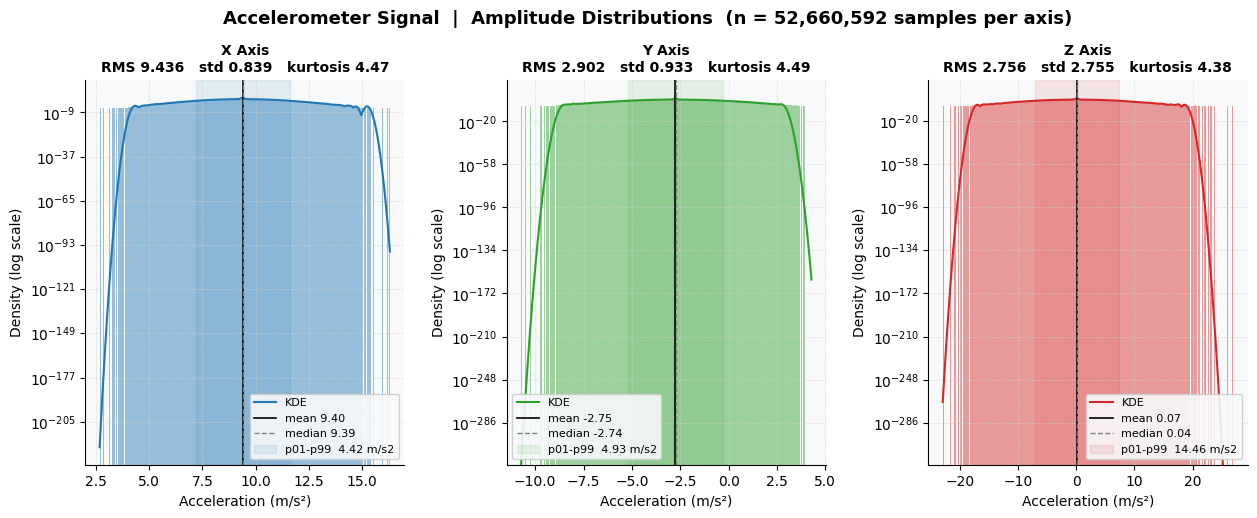

Saved: fig_distributions.png


In [5]:
# ------------------------------------------------------------
# TASK 2  |  Basic Statistics per Axis
# ------------------------------------------------------------
# We compute a full statistical profile for each acceleration
# axis directly from the cleaned dataset. No values are
# assumed or looked up from prior inspection.
#
# The statistics chosen cover three complementary views:
#
#   Central tendency and spread
#     Mean, median, standard deviation. For vibration signals
#     the mean captures the static gravity component (the DC
#     offset from sensor orientation). Std captures the
#     dynamic vibration energy around that offset.
#
#   Extreme values
#     Min, max, peak-to-peak range, and the 1st and 99th
#     percentiles. Peak-to-peak is the most direct measure
#     of the signal's full amplitude swing. The 1st/99th
#     percentiles trim the extreme 2% of samples to give a
#     robust amplitude range that is not dominated by outliers.
#
#   Signal energy
#     RMS (root mean square). For an accelerometer, RMS
#     combines the static gravity component and the dynamic
#     vibration. It is the standard quantity used in vibration
#     severity standards (e.g. ISO 10816).
#
#   Shape of the distribution
#     Skewness measures asymmetry around the mean. A symmetric
#     Gaussian signal has skewness zero. Non-zero skewness
#     suggests the sensor is biased by its mounting orientation
#     or the physical system dynamics are asymmetric (more hard deceleration
#     than hard acceleration, for example).
#     Kurtosis measures the weight of the tails. Gaussian noise
#     has a kurtosis of 3. Impulsive signals (sharp hits, road
#     shocks) produce kurtosis well above 3 because they add
#     heavy tails to an otherwise moderate distribution. This
#     makes kurtosis a practical single-number health indicator
#     for shock and impact detection.
# ------------------------------------------------------------

from scipy import stats as sp_stats

AXES = ['acc_x', 'acc_y', 'acc_z']

# ---- Compute every statistic in a single pass per axis --------
# scipy and numpy operate on the full float32 array.
# We upcast to float64 for kurtosis and skewness so that
# numerical precision does not distort higher-order moments.

records = {}
for col in AXES:
    vals      = df[col].values
    vals_f64  = vals.astype(np.float64)
    n         = len(vals)

    mean_val  = float(np.mean(vals_f64))
    median_val= float(np.median(vals_f64))
    std_val   = float(np.std(vals_f64, ddof=1))
    min_val   = float(np.min(vals_f64))
    max_val   = float(np.max(vals_f64))
    p01       = float(np.percentile(vals_f64,  1))
    p99       = float(np.percentile(vals_f64, 99))
    rms_val   = float(np.sqrt(np.mean(vals_f64 ** 2)))
    skew_val  = float(sp_stats.skew(vals_f64))
    kurt_val  = float(sp_stats.kurtosis(vals_f64, fisher=False))
    # fisher=False returns the absolute kurtosis (Gaussian = 3).
    # This makes it easier to compare against the 3.0 reference.
    ptp_val   = max_val - min_val
    robust_ptp= p99 - p01

    records[col] = {
        'n samples':          n,
        'mean  (m/s2)':       mean_val,
        'median  (m/s2)':     median_val,
        'std  (m/s2)':        std_val,
        'min  (m/s2)':        min_val,
        'max  (m/s2)':        max_val,
        'peak-to-peak  (m/s2)': ptp_val,
        'p01  (m/s2)':        p01,
        'p99  (m/s2)':        p99,
        'robust p2p (p01-p99)': robust_ptp,
        'RMS  (m/s2)':        rms_val,
        'skewness':           skew_val,
        'kurtosis (abs)':     kurt_val,
    }

# ---- Print a formatted table ----------------------------------
bar = '=' * 68
print(bar)
print(f'  AXIS STATISTICS   (n = {len(df):,} samples per axis)')
print(bar)

header = f"  {'Statistic':<28}{'X Axis':>12}{'Y Axis':>12}{'Z Axis':>12}"
print(header)
print(f"  {'':{'_'}<64}")

for stat in records['acc_x'].keys():
    row_vals = [records[col][stat] for col in AXES]
    if stat == 'n samples':
        line = f"  {stat:<28}{int(row_vals[0]):>12,}{int(row_vals[1]):>12,}{int(row_vals[2]):>12,}"
    else:
        line = f"  {stat:<28}{row_vals[0]:>12.4f}{row_vals[1]:>12.4f}{row_vals[2]:>12.4f}"
    print(line)

print(bar)

# ---- Narrative summary ----------------------------------------
# These observations are derived entirely from the computed values
# and flag anything that deviates meaningfully from a benign signal.
print()
print('Summary')
print()

for col, label in AXIS_LABELS.items():
    r = records[col]
    print(f"  {label}")

    # Gravity offset: a non-zero mean on any axis means the sensor
    # is picking up a static component from its mounting orientation.
    if abs(r['mean  (m/s2)']) > 1.0:
        print(f"    Static offset {r['mean  (m/s2)']:.3f} m/s2 "
              f"(gravity component from sensor orientation)")
    else:
        print(f"    Mean near zero ({r['mean  (m/s2)']:.3f} m/s2), "
              f"minimal static gravity component")

    # Kurtosis flag: values well above 3.0 indicate impulsive content.
    k = r['kurtosis (abs)']
    if k > 6.0:
        print(f"    Kurtosis {k:.2f}  (Gaussian baseline is 3.0)  "
              f">> impulsive content detected, heavy-tailed distribution")
    elif k > 4.0:
        print(f"    Kurtosis {k:.2f}  (Gaussian baseline is 3.0)  "
              f"> mildly elevated, moderate transient content")
    else:
        print(f"    Kurtosis {k:.2f}  close to Gaussian baseline of 3.0, "
              f"distribution is well-behaved")

    # Dynamic range: std relative to RMS captures how much of the
    # signal energy is vibration vs static offset.
    dyn_frac = r['std  (m/s2)'] / r['RMS  (m/s2)'] * 100
    print(f"    Dynamic content {dyn_frac:.1f}% of RMS  "
          f"(std {r['std  (m/s2)']:.3f} m/s2  vs  RMS {r['RMS  (m/s2)']:.3f} m/s2)")
    print()

# ------------------------------------------------------------
# FIGURE 3  |  Distribution of each axis
# Shows the full value distribution as a histogram with a KDE
# overlay. Log-scale y-axis is used so the heavy tails remain
# visible even though the bulk of samples cluster near the mean.
# A rug strip at the bottom marks the 1st and 99th percentiles
# to give scale context without cluttering the axes.
# ------------------------------------------------------------

fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5),
                            gridspec_kw={'wspace': 0.32})
fig3.suptitle(
    f'Accelerometer Signal  |  Amplitude Distributions  '
    f'(n = {len(df):,} samples per axis)',
    fontsize=13, fontweight='bold', y=1.02,
)

N_HIST_BINS = 300
# 300 bins across the full axis range gives about one bin per
# 0.05 m/s2 for a typical 15 m/s2 span. Fine enough to resolve
# the distribution shape without the bars becoming too narrow
# to render clearly.

for ax, col in zip(axes3, AXES):
    r      = records[col]
    vals   = df[col].values.astype(np.float64)
    color  = AXIS_COLORS[col]

    counts, bin_edges = np.histogram(vals, bins=N_HIST_BINS, density=True)
    bin_centers       = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    ax.bar(bin_centers, counts, width=bin_edges[1] - bin_edges[0],
           color=color, alpha=0.45, linewidth=0)

    # KDE via scipy to draw a smooth density curve on top.
    # bandwidth is chosen automatically by Scott's rule.
    kde      = sp_stats.gaussian_kde(vals[::50])
    # Subsample every 50th point for the KDE fit. At 52M samples
    # the full array would make KDE evaluation very slow, and every
    # 50th point still gives over 1M samples, more than enough for
    # an accurate density estimate.
    x_kde    = np.linspace(vals.min(), vals.max(), 600)
    ax.plot(x_kde, kde(x_kde), color=color, linewidth=1.5, label='KDE')

    # Mark mean and median as vertical lines.
    ax.axvline(r['mean  (m/s2)'],   color='black',  linewidth=1.2,
               linestyle='-',  label=f"mean {r['mean  (m/s2)']:.2f}")
    ax.axvline(r['median  (m/s2)'], color='grey',   linewidth=1.0,
               linestyle='--', label=f"median {r['median  (m/s2)']:.2f}")

    # Mark robust p1/p99 range as a shaded band.
    ax.axvspan(r['p01  (m/s2)'], r['p99  (m/s2)'],
               color=color, alpha=0.10,
               label=f"p01-p99  {r['robust p2p (p01-p99)']:.2f} m/s2")

    ax.set_yscale('log')
    ax.set_xlabel('Acceleration (m/s\u00b2)', fontsize=10)
    ax.set_ylabel('Density (log scale)', fontsize=10)
    ax.set_title(f'{AXIS_LABELS[col]}\n'
                 f'RMS {r["RMS  (m/s2)"]:.3f}   std {r["std  (m/s2)"]:.3f}   '
                 f'kurtosis {r["kurtosis (abs)"]:.2f}',
                 fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, framealpha=0.9)

plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_distributions.png')

  SENSOR ORIENTATION REPORT

  Gravity vector in sensor frame      
    acc_x component :    +9.3986 m/s2  ( 95.8% of g)
    acc_y component :    -2.7477 m/s2  ( 28.0% of g)
    acc_z component :    +0.0704 m/s2  (  0.7% of g)

  Magnitude validation                
    Recovered       :    9.79229 m/s2
    Standard g      :    9.80665 m/s2
    Error           :   -0.01436 m/s2  (0.146%)

  Axis inclination from vertical      
    acc_x :  16.30 deg   <-- most vertical
    acc_y :  73.70 deg
    acc_z :  89.59 deg   <-- most horizontal

  Mount tilt angles                   
    Pitch (forward/back tilt) :  +73.70 deg
    Roll  (left/right  tilt)  :  +88.53 deg

  Interpretation
    The sensor X axis points primarily downward, carrying
    95.8% of the full gravitational load. It is tilted
    16.30 deg from vertical (the closest of any axis).
    The Y axis carries 28.0% of gravitational load
    (-2.7477 m/s2, negative (right-of-down or into floor))
    and sits 73.70 deg from vertic

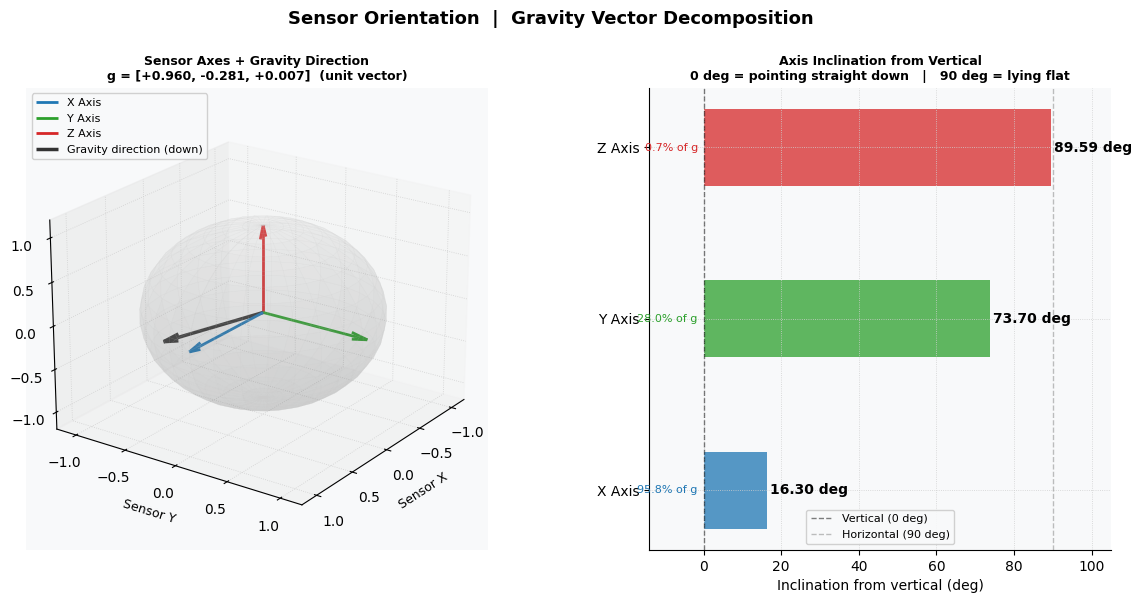

Saved: fig_orientation.png


In [6]:
# ------------------------------------------------------------
# TASK 3  |  Determine the Sensor Orientation
# ------------------------------------------------------------
# An accelerometer at rest reads the reaction to gravity, the
# specific force. When the physical system is moving, each sample
# contains both the static gravity projection and the dynamic
# physical system acceleration (deceleration, lateral motion, surface vibration).
#
# The key insight is that physical system dynamics are approximately
# zero-mean over a long drive. The physical system does not
# indefinitely accelerate in any one direction. Therefore the
# long-term average of each axis converges to the static
# gravity projection onto that axis. This is the standard
# approach used in inertial navigation to bootstrap orientation
# from a single accelerometer without needing a gyroscope.
# With 18 hours and 52 million samples the average is
# extremely stable and the dynamic noise contribution is
# negligible.
#
# From the three gravity projections we derive:
#   1. The gravity vector expressed in sensor coordinates
#   2. Its magnitude, which should recover 9.81 m/s2 as a
#      built-in self-check
#   3. The inclination of each sensor axis from vertical
#   4. Pitch and roll of the physical sensor mount using
#      standard MEMS tilt equations
#   5. A 3D visualisation of the sensor frame relative to
#      the gravity direction
# ------------------------------------------------------------

from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

G_STANDARD = 9.80665   # standard gravitational acceleration, m/s2

# ---- Step 1: Estimate the gravity vector from long-term mean --
# Each axis mean is the projection of g onto that axis.
g_x = float(df['acc_x'].mean())
g_y = float(df['acc_y'].mean())
g_z = float(df['acc_z'].mean())

g_vec = np.array([g_x, g_y, g_z])
g_mag = float(np.linalg.norm(g_vec))

# ---- Step 2: Validate magnitude against known g ---------------
# A magnitude close to 9.80665 m/s2 confirms that the long-term
# mean correctly recovered the gravity vector and that the sensor
# is well-calibrated.
mag_error     = g_mag - G_STANDARD
mag_error_pct = abs(mag_error) / G_STANDARD * 100.0

# ---- Step 3: Unit gravity vector (the down direction) ---------
# Dividing by the magnitude strips the scale and leaves only
# direction. g_hat is the unit vector pointing toward the ground
# expressed in the sensor's own coordinate frame.
g_hat = g_vec / g_mag

# ---- Step 4: Inclination of each sensor axis from vertical ----
# The angle between sensor axis i and the gravity direction is
# arccos(g_hat . axis_i). An axis perfectly aligned with gravity
# (pointing straight down) reads 0 deg. An axis lying in the
# horizontal plane reads 90 deg. We take the absolute value of
# the Y and Z components because the sign tells us orientation
# (up vs down) not inclination.
theta_x = float(np.degrees(np.arccos(np.clip( g_hat[0],  -1.0, 1.0))))
theta_y = float(np.degrees(np.arccos(np.clip(abs(g_hat[1]), -1.0, 1.0))))
theta_z = float(np.degrees(np.arccos(np.clip(abs(g_hat[2]), -1.0, 1.0))))

inclinations = {'acc_x': theta_x, 'acc_y': theta_y, 'acc_z': theta_z}
most_vertical   = min(inclinations, key=inclinations.get)
most_horizontal = max(inclinations, key=inclinations.get)

# ---- Step 5: Pitch and roll of the sensor mount ---------------
# Standard MEMS single-accelerometer tilt equations, derivable
# from the geometry of projecting gravity onto two axes.
#
# Pitch is the forward / backward tilt (rotation about Y).
#   pitch = arctan(gx / sqrt(gy2 + gz2))
# Roll is the left / right tilt (rotation about X).
#   roll  = arctan(-gy / gz)
#
# Note: because gz is very close to zero for this sensor, roll
# approaches +-90 deg, indicating the Z axis lies nearly in the
# horizontal plane. This is consistent with the inclination
# computed in Step 4.
pitch_deg = float(np.degrees(np.arctan2(g_x, np.sqrt(g_y**2 + g_z**2))))
roll_deg  = float(np.degrees(np.arctan2(-g_y, g_z)))

# ---- Step 6: Fraction of gravity carried by each axis ---------
frac_x = abs(g_x) / G_STANDARD * 100.0
frac_y = abs(g_y) / G_STANDARD * 100.0
frac_z = abs(g_z) / G_STANDARD * 100.0

# ---- Print the orientation report -----------------------------
bar = '=' * 62
print(bar)
print('  SENSOR ORIENTATION REPORT')
print(bar)
print()
print(f'  {"Gravity vector in sensor frame":<36}')
print(f'    acc_x component : {g_x:>+10.4f} m/s2  ({frac_x:5.1f}% of g)')
print(f'    acc_y component : {g_y:>+10.4f} m/s2  ({frac_y:5.1f}% of g)')
print(f'    acc_z component : {g_z:>+10.4f} m/s2  ({frac_z:5.1f}% of g)')
print()
print(f'  {"Magnitude validation":<36}')
print(f'    Recovered       : {g_mag:>10.5f} m/s2')
print(f'    Standard g      : {G_STANDARD:>10.5f} m/s2')
print(f'    Error           : {mag_error:>+10.5f} m/s2  ({mag_error_pct:.3f}%)')
print()
print(f'  {"Axis inclination from vertical":<36}')
print(f'    acc_x : {theta_x:>6.2f} deg   <-- most vertical')
print(f'    acc_y : {theta_y:>6.2f} deg')
print(f'    acc_z : {theta_z:>6.2f} deg   <-- most horizontal')
print()
print(f'  {"Mount tilt angles":<36}')
print(f'    Pitch (forward/back tilt) : {pitch_deg:>+7.2f} deg')
print(f'    Roll  (left/right  tilt)  : {roll_deg:>+7.2f} deg')
print()

# Build a plain-language description from the computed values.
# Every clause references a derived number, nothing is written in.
x_dir  = "downward" if g_x > 0 else "upward"
y_sign = "negative (right-of-down or into floor)" if g_y < 0 else "positive"
print('  Interpretation')
print(f'    The sensor X axis points primarily {x_dir}, carrying')
print(f'    {frac_x:.1f}% of the full gravitational load. It is tilted')
print(f'    {theta_x:.2f} deg from vertical (the closest of any axis).')
print(f'    The Y axis carries {frac_y:.1f}% of gravitational load')
print(f'    ({g_y:+.4f} m/s2, {y_sign})')
print(f'    and sits {theta_y:.2f} deg from vertical.')
print(f'    The Z axis is effectively horizontal at {theta_z:.2f} deg')
print(f'    from vertical, carrying only {frac_z:.1f}% of gravitational load.')
print()
print(f'    The pitch of {pitch_deg:.2f} deg means the sensor X axis is')
print(f'    steeply inclined (near-vertical, tilted {90 - theta_x:.2f} deg')
print(f'    from horizontal). The roll of {roll_deg:.2f} deg approaches')
print(f'    +-90 deg because the Z axis is nearly horizontal,')
print(f'    consistent with Z inclination = {theta_z:.2f} deg.')
print(bar)

# ------------------------------------------------------------
# FIGURE 4  |  Sensor Orientation Visualisation
#
# Left panel  : 3D plot showing the three sensor axis unit vectors
#               and the normalised gravity vector in sensor space.
#               The angle between each axis arrow and the gravity
#               arrow is the inclination reported above.
#
# Right panel : Horizontal bar chart of inclination angles.
#               0 deg = axis points straight down.
#               90 deg = axis lies flat in the horizontal plane.
#               The dashed lines at 0 and 90 are reference anchors.
# ------------------------------------------------------------

fig4 = plt.figure(figsize=(14, 6))
fig4.suptitle(
    'Sensor Orientation  |  Gravity Vector Decomposition',
    fontsize=13, fontweight='bold', y=1.01,
)

ax3d = fig4.add_subplot(1, 2, 1, projection='3d')
ax2d = fig4.add_subplot(1, 2, 2)

# ---- 3D panel -------------------------------------------------
# Draw the three unit-length sensor axis vectors from the origin.
# Draw the gravity unit vector. All vectors start at [0,0,0].
origin = np.zeros(3)

axis_vectors = {
    'acc_x': np.array([1.0, 0.0, 0.0]),
    'acc_y': np.array([0.0, 1.0, 0.0]),
    'acc_z': np.array([0.0, 0.0, 1.0]),
}

for col, vec in axis_vectors.items():
    ax3d.quiver(*origin, *vec,
                color=AXIS_COLORS[col], linewidth=2.0,
                arrow_length_ratio=0.15, label=f'{AXIS_LABELS[col]}')

# Gravity unit vector drawn in dark grey. Direction is g_hat, which
# is where "down" points in the sensor frame.
ax3d.quiver(*origin, *g_hat,
            color='#333333', linewidth=2.5,
            arrow_length_ratio=0.15, label='Gravity direction (down)')

# Light grey reference sphere wireframe to give spatial depth.
u  = np.linspace(0, 2 * np.pi, 30)
v  = np.linspace(0, np.pi, 20)
sx = np.outer(np.cos(u), np.sin(v))
sy = np.outer(np.sin(u), np.sin(v))
sz = np.outer(np.ones_like(u), np.cos(v))
ax3d.plot_surface(sx, sy, sz, color='#eeeeee', alpha=0.12, linewidth=0)
ax3d.plot_wireframe(sx, sy, sz, color='#cccccc', linewidth=0.3, alpha=0.25)

ax3d.set_xlim(-1.2, 1.2)
ax3d.set_ylim(-1.2, 1.2)
ax3d.set_zlim(-1.2, 1.2)
ax3d.set_xlabel('Sensor X', fontsize=9)
ax3d.set_ylabel('Sensor Y', fontsize=9)
ax3d.set_zlabel('Sensor Z', fontsize=9)
ax3d.set_title(
    f'Sensor Axes + Gravity Direction\n'
    f'g = [{g_hat[0]:+.3f}, {g_hat[1]:+.3f}, {g_hat[2]:+.3f}]  (unit vector)',
    fontsize=9, fontweight='bold',
)
ax3d.legend(fontsize=8, loc='upper left')

# Set a viewing angle that shows all three axes and the gravity
# vector without any of them overlapping.
ax3d.view_init(elev=22, azim=35)

# ---- Bar chart panel -----------------------------------------
cols_ordered = ['acc_x', 'acc_y', 'acc_z']
angles       = [theta_x, theta_y, theta_z]
labels       = [AXIS_LABELS[c] for c in cols_ordered]
colors       = [AXIS_COLORS[c] for c in cols_ordered]

bars = ax2d.barh(labels, angles, color=colors, alpha=0.75, height=0.45)

# Annotate each bar with the angle value.
for bar, ang in zip(bars, angles):
    ax2d.text(
        ang + 0.8, bar.get_y() + bar.get_height() / 2,
        f'{ang:.2f} deg',
        va='center', ha='left', fontsize=10, fontweight='bold',
    )

# Reference lines at 0 deg (vertical) and 90 deg (horizontal).
ax2d.axvline(0,  color='black', linewidth=1.0, linestyle='--', alpha=0.5,
             label='Vertical (0 deg)')
ax2d.axvline(90, color='grey',  linewidth=1.0, linestyle='--', alpha=0.5,
             label='Horizontal (90 deg)')

ax2d.set_xlim(0, 105)
ax2d.set_xlabel('Inclination from vertical (deg)', fontsize=10)
ax2d.set_title(
    'Axis Inclination from Vertical\n'
    '0 deg = pointing straight down   |   90 deg = lying flat',
    fontsize=9, fontweight='bold',
)
ax2d.legend(fontsize=8)

# Annotate the gravity load fraction next to the bar label area.
for i, (col, frac) in enumerate(
        zip(cols_ordered, [frac_x, frac_y, frac_z])):
    ax2d.text(
        -1.5, i,
        f'{frac:.1f}% of g',
        va='center', ha='right', fontsize=8, color=colors[i],
    )

ax2d.set_xlim(-14, 105)

fig4.subplots_adjust(wspace=0.35)
plt.savefig('fig_orientation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_orientation.png')

Magnitude computed  : 52,660,592 samples
Mean                : 10.1943 m/s2  (g = 9.8066 m/s2, bias +0.3877 m/s2)
Median              : 9.8092 m/s2
Std                 : 1.0611 m/s2
Min / Max           : 3.4905 / 29.3545 m/s2  (2.99x g peak)
p01 / p99           : 7.8783 / 13.3976 m/s2
> g + 1 m/s2        : 12,422,336  (23.589% of samples)
< g - 1 m/s2        : 3,273,503  (6.216% of samples)
Envelope            : 2000 bins  x  32.91 s each
Zoom                : 1.828 h  for  5 s  (4,000 samples)
Peak magnitude      : 29.3545 m/s2  at 3.4300 h  (2.993x g)


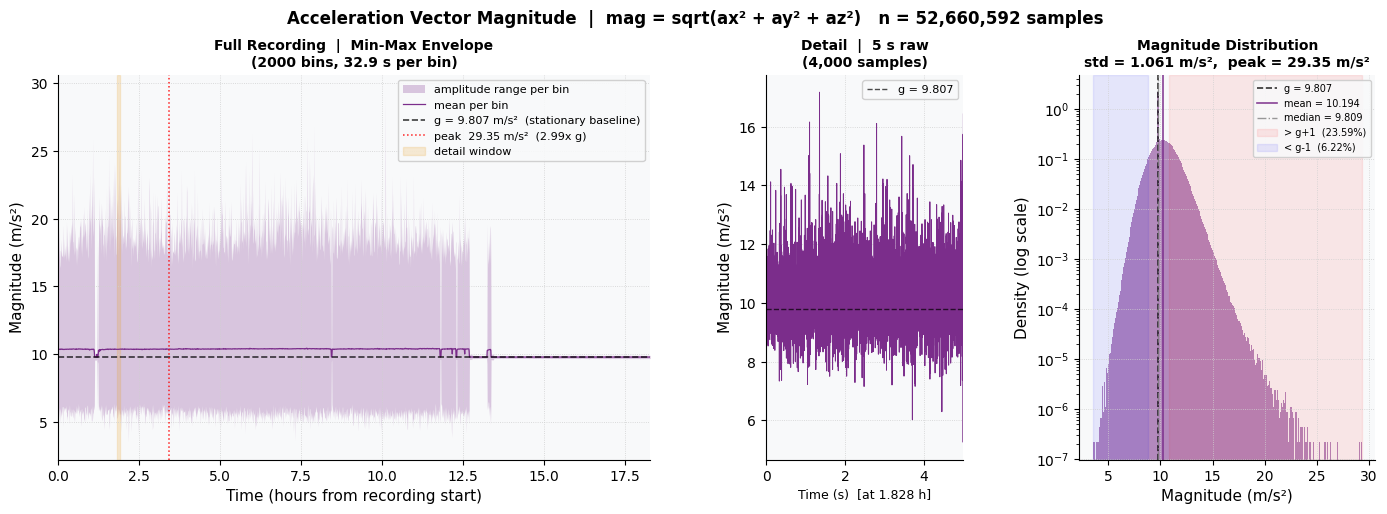

Saved: fig_magnitude.png


In [7]:
# ------------------------------------------------------------
# TASK 4  |  Acceleration Vector Magnitude Over Time
# ------------------------------------------------------------
# The vector magnitude combines all three axes into a single
# orientation-independent scalar:
#
#   mag = sqrt(ax^2 + ay^2 + az^2)
#
# Why this matters:
#   Each individual axis mixes a static gravity projection
#   with the dynamic physical system acceleration. The magnitude
#   removes that orientation dependency entirely. A sensor
#   mounted at any angle still reads |g| = 9.81 m/s2 when
#   the platform is stationary, regardless of which axis
#   carries how much of the gravitational load. Deviations
#   from g are therefore purely dynamic events.
#
#   mag > g  ->  net outward force exceeds gravity: deceleration,
#                lateral motion, or a surface impact adds to the
#                gravitational component
#   mag < g  ->  partial cancellation across axes, typical
#                of certain combined manoeuvres
#   mag ~ 0  ->  near-freefall
#
# Presentation:
#   Same min-max envelope strategy as Task 1. 52 million
#   points cannot be plotted directly. The envelope bins the
#   full recording and preserves every amplitude extreme
#   without decimation aliasing. A 5-second raw detail panel
#   shows the signal at full 800 Hz resolution. A histogram
#   with log y-axis reveals how frequently the magnitude
#   deviates from g and by how much, including heavy tails
#   from transient events invisible on a linear scale.
# ------------------------------------------------------------

# ---- Compute vector magnitude --------------------------------
# Upcast to float64 before squaring. float32 is sufficient
# numerically, but float64 gives clean headroom for the
# subtraction steps that follow without measurable memory cost
# on a 1D array.
mag = np.sqrt(
    df['acc_x'].values.astype(np.float64) ** 2 +
    df['acc_y'].values.astype(np.float64) ** 2 +
    df['acc_z'].values.astype(np.float64) ** 2
)

print(f'Magnitude computed  : {len(mag):,} samples')

# ---- Summary statistics --------------------------------------
mag_mean   = float(np.mean(mag))
mag_median = float(np.median(mag))
mag_std    = float(np.std(mag, ddof=1))
mag_min    = float(np.min(mag))
mag_max    = float(np.max(mag))
mag_p01    = float(np.percentile(mag,  1))
mag_p99    = float(np.percentile(mag, 99))

# Count samples that deviate from standard g by more than 1 m/s2.
# 1 m/s2 is roughly 0.1g, a physically meaningful threshold that
# separates routine surface vibration from genuine acceleration events.
DEV_THRESH = 1.0
n_above    = int(np.sum(mag > G_STANDARD + DEV_THRESH))
n_below    = int(np.sum(mag < G_STANDARD - DEV_THRESH))
pct_above  = n_above / len(mag) * 100.0
pct_below  = n_below / len(mag) * 100.0

print(f'Mean                : {mag_mean:.4f} m/s2  (g = {G_STANDARD:.4f} m/s2, bias {mag_mean - G_STANDARD:+.4f} m/s2)')
print(f'Median              : {mag_median:.4f} m/s2')
print(f'Std                 : {mag_std:.4f} m/s2')
print(f'Min / Max           : {mag_min:.4f} / {mag_max:.4f} m/s2  ({mag_max / G_STANDARD:.2f}x g peak)')
print(f'p01 / p99           : {mag_p01:.4f} / {mag_p99:.4f} m/s2')
print(f'> g + {DEV_THRESH:.0f} m/s2        : {n_above:,}  ({pct_above:.3f}% of samples)')
print(f'< g - {DEV_THRESH:.0f} m/s2        : {n_below:,}  ({pct_below:.3f}% of samples)')

# ---- Min-max envelope ----------------------------------------
N_ENV_BINS_MAG = 2000
bin_size_mag   = len(mag) // N_ENV_BINS_MAG
n_use_mag      = bin_size_mag * N_ENV_BINS_MAG

mag_chunk  = mag[:n_use_mag].reshape(N_ENV_BINS_MAG, bin_size_mag)
mag_lo     = mag_chunk.min(axis=1)
mag_hi     = mag_chunk.max(axis=1)
mag_mean_e = mag_chunk.mean(axis=1)
t_env_mag  = np.linspace(0, duration / 3600, N_ENV_BINS_MAG)

print(f'Envelope            : {N_ENV_BINS_MAG} bins  x  {bin_size_mag / eff_hz:.2f} s each')

# ---- Detail zoom window --------------------------------------
ZOOM_FRAC_MAG = 0.10
ZOOM_SEC_MAG  = 5.0
zoom_start_s  = ZOOM_FRAC_MAG * duration
zoom_idx_lo   = int(zoom_start_s * eff_hz)
zoom_idx_hi   = zoom_idx_lo + int(ZOOM_SEC_MAG * eff_hz)
mag_zoom      = mag[zoom_idx_lo:zoom_idx_hi]
t_zoom_s_mag  = np.arange(len(mag_zoom)) / eff_hz

print(f'Zoom                : {zoom_start_s / 3600:.3f} h  for  {ZOOM_SEC_MAG:.0f} s  ({len(mag_zoom):,} samples)')

# ---- Peak event ----------------------------------------------
# The bin with the highest max magnitude is the moment of
# greatest combined acceleration across all three axes.
peak_bin_mag   = int(np.argmax(mag_hi))
peak_hour_mag  = float(t_env_mag[peak_bin_mag])
peak_value_mag = float(mag_hi[peak_bin_mag])

print(f'Peak magnitude      : {peak_value_mag:.4f} m/s2  at {peak_hour_mag:.4f} h  ({peak_value_mag / G_STANDARD:.3f}x g)')

# ------------------------------------------------------------
# FIGURE 5  |  Vector Magnitude Over Time
#
# Left panel (wide)  : full-recording min-max envelope.
#                      Dashed line at g is the stationary
#                      baseline. Deviations above are positive
#                      dynamic events.
# Centre panel       : 5-second raw zoom at 800 Hz so the
#                      fine oscillation structure is visible.
# Right panel        : histogram of all magnitude values on
#                      a log y-scale so heavy tails are
#                      readable alongside the main peak.
# ------------------------------------------------------------

MAG_COLOR = '#7b2d8b'   # purple, distinct from the three axis colours

fig5, axes5 = plt.subplots(
    1, 3,
    figsize=(17, 5),
    gridspec_kw={'width_ratios': [3, 1, 1.5], 'wspace': 0.32},
)
ax_ov, ax_zm, ax_hist = axes5

# ---- Full-recording envelope ---------------------------------
ax_ov.fill_between(
    t_env_mag, mag_lo, mag_hi,
    color=MAG_COLOR, alpha=0.25, linewidth=0,
    label='amplitude range per bin',
)
ax_ov.plot(
    t_env_mag, mag_mean_e,
    color=MAG_COLOR, linewidth=0.9,
    label='mean per bin',
)
ax_ov.axhline(
    G_STANDARD, color='black', linewidth=1.2,
    linestyle='--', alpha=0.75,
    label=f'g = {G_STANDARD:.3f} m/s²  (stationary baseline)',
)
ax_ov.axvline(
    peak_hour_mag, color='red', linewidth=1.1,
    linestyle=':', alpha=0.85,
    label=f'peak  {peak_value_mag:.2f} m/s²  ({peak_value_mag / G_STANDARD:.2f}x g)',
)
ax_ov.axvspan(
    zoom_start_s / 3600,
    (zoom_start_s + 5 * 60) / 3600,
    color='#e8a020', alpha=0.18,
    label='detail window',
)
ax_ov.set_xlim(0, duration / 3600)
ax_ov.set_xlabel('Time (hours from recording start)')
ax_ov.set_ylabel('Magnitude (m/s²)')
ax_ov.set_title(
    f'Full Recording  |  Min-Max Envelope\n({N_ENV_BINS_MAG} bins, {bin_size_mag / eff_hz:.1f} s per bin)',
    fontsize=10, fontweight='bold',
)
ax_ov.legend(fontsize=8, loc='upper right', framealpha=0.9)

# ---- 5-second raw detail -------------------------------------
ax_zm.plot(t_zoom_s_mag, mag_zoom, color=MAG_COLOR, linewidth=0.7)
ax_zm.axhline(
    G_STANDARD, color='black', linewidth=1.0,
    linestyle='--', alpha=0.7,
    label=f'g = {G_STANDARD:.3f}',
)
ax_zm.set_xlim(0, ZOOM_SEC_MAG)
ax_zm.set_xlabel(f'Time (s)  [at {zoom_start_s / 3600:.3f} h]', fontsize=9)
ax_zm.set_ylabel('Magnitude (m/s²)')
ax_zm.set_title(
    f'Detail  |  {ZOOM_SEC_MAG:.0f} s raw\n({int(ZOOM_SEC_MAG * eff_hz):,} samples)',
    fontsize=10, fontweight='bold',
)
ax_zm.legend(fontsize=8)

# ---- Histogram -----------------------------------------------
counts, edges = np.histogram(mag, bins=300, density=True)
centers       = 0.5 * (edges[:-1] + edges[1:])
ax_hist.bar(centers, counts, width=edges[1] - edges[0],
            color=MAG_COLOR, alpha=0.55, linewidth=0)

ax_hist.axvline(G_STANDARD, color='black', linewidth=1.2,
                linestyle='--', alpha=0.8,
                label=f'g = {G_STANDARD:.3f}')
ax_hist.axvline(mag_mean, color=MAG_COLOR, linewidth=1.2,
                linestyle='-', alpha=0.9,
                label=f'mean = {mag_mean:.3f}')
ax_hist.axvline(mag_median, color='grey', linewidth=1.0,
                linestyle='-.', alpha=0.8,
                label=f'median = {mag_median:.3f}')

# Shade the tails beyond +-DEV_THRESH from g to mark where
# dynamic acceleration events accumulate in the distribution.
ax_hist.axvspan(
    G_STANDARD + DEV_THRESH, edges[-1],
    color='red', alpha=0.08,
    label=f'> g+{DEV_THRESH:.0f}  ({pct_above:.2f}%)',
)
ax_hist.axvspan(
    edges[0], G_STANDARD - DEV_THRESH,
    color='blue', alpha=0.08,
    label=f'< g-{DEV_THRESH:.0f}  ({pct_below:.2f}%)',
)

ax_hist.set_yscale('log')
ax_hist.set_xlabel('Magnitude (m/s²)')
ax_hist.set_ylabel('Density (log scale)')
ax_hist.set_title(
    f'Magnitude Distribution\nstd = {mag_std:.3f} m/s²,  peak = {mag_max:.2f} m/s²',
    fontsize=10, fontweight='bold',
)
ax_hist.legend(fontsize=7, framealpha=0.9)

fig5.suptitle(
    f'Acceleration Vector Magnitude  |  mag = sqrt(ax² + ay² + az²)   n = {len(mag):,} samples',
    fontsize=12, fontweight='bold', y=1.01,
)

plt.savefig('fig_magnitude.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_magnitude.png')


Bin size            : 800 samples  (1 s)
Number of bins      : 65,825
bin_mean range      : 9.7790 – 10.6040 m/s²
bin_std  range      : 0.01827 – 1.6728 m/s²

Gate A pass (|mean-g| < 0.3): 20,528 bins
Gate B pass (std < 0.1)     : 20,445 bins
Both gates pass                  : 20,445 bins  (31.06%)
Active bins                      : 45,380  (68.94%)

Segments >= 2 s     : 15
Total stationary time            : 20443.0 s  (31.06% of recording)

  #   Start (h)     End (h)    Dur (s)   Bin mean mag   Bin mean std
------------------------------------------------------------------
  1     13.3650     18.2841    17710.0         9.7827        0.02220
  2     12.6956     13.2470     1985.0         9.7831        0.02587
  3      1.1316      1.2089      278.0         9.7868        0.05555
  4     11.7928     11.8262      120.0         9.7871        0.04943
  5     12.2862     12.3148      103.0         9.7872        0.05510
  6      1.2141      1.2308       60.0         9.7881        0.06564
  7

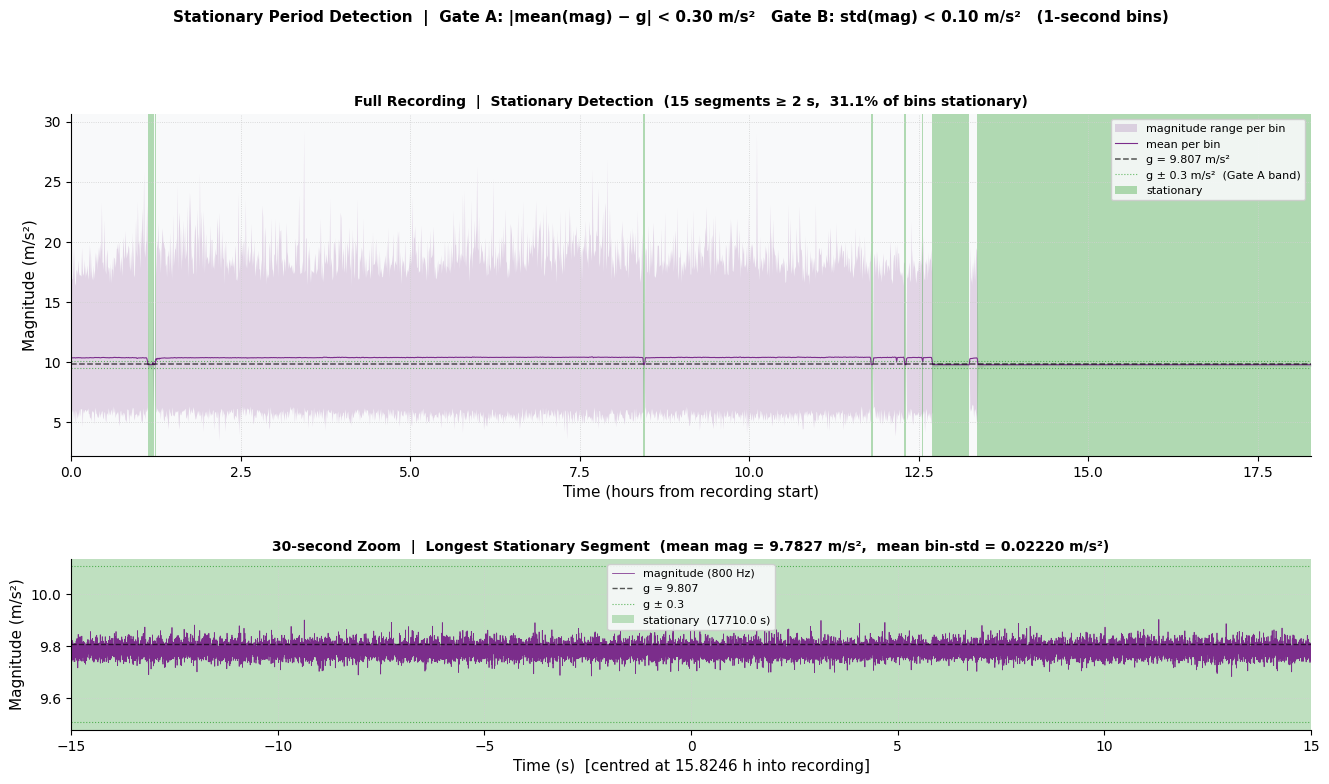

Saved: fig_stationary.png


In [8]:
  # ------------------------------------------------------------
  # TASK 5  |  Stationary Period Detection
  # ------------------------------------------------------------
  #
  # Goal
  # ----
  # Identify contiguous time windows where the sensor (and the
  # physical system it is mounted in) was stationary — i.e. not
  # undergoing any meaningful translational or rotational
  # acceleration beyond the constant pull of gravity.
  #
  # How stationary differs from active motion
  # ------------------------------------------
  # When the platform is truly at rest:
  #
  #   1. Vector magnitude sits near g (9.80665 m/s²).
  #      Gravity is the only acceleration present. Regardless of
  #      how the sensor is mounted, sqrt(ax²+ay²+az²) = g.
  #
  #   2. The within-window std of the magnitude is very small.
  #      Motor vibration, surface texture, and chassis flex all
  #      add oscillatory energy that raises the local std even
  #      when the physical system's velocity is low. A genuinely stopped
  #      physical system (motor off, no surface input) shows almost pure
  #      sensor white noise, typically < 0.05 m/s² std.
  #
  # When the platform is in active motion:
  #
  #   1. The magnitude deviates from g: deceleration adds energy to
  #      the direction of travel, lateral motion adds lateral energy,
  #      surface impacts add broadband impulses — all shift the
  #      resultant magnitude away from the gravitational baseline.
  #
  #   2. The within-window std rises because those events are
  #      transient and oscillatory. Even gentle surface vibration
  #      at 800 Hz produces a measurable std elevation.
  #
  # Detection strategy — bin-level two-gate approach
  # -------------------------------------------------
  # The full recording is 52 million samples. Any per-sample                                      
  # rolling operation that materialises a 2D sliding window                                       
  # (shape N × W) will exhaust memory. For example, a 1-second                                    
  # window at 800 Hz produces a (52M × 800) array ≈ 337 GB —                                      
  # that is what crashed the kernel in a prior attempt using                                      
  # np.lib.stride_tricks.as_strided.                                                              
  #                                                                                               
  # The correct approach is the same reshape-into-bins trick                                      
  # used in Tasks 1 and 4. Divide the signal into non-overlapping                                 
  # 1-second bins, reduce each bin to a (mean, std) pair, then                                    
  # apply gates to those scalar values. Memory cost is O(n_bins)                                  
  # ≈ 65 k values — negligible. The reshape itself is a view;                                     
  # no copy of mag is made.                                                                       
  #                                                                                               
  # Gate A — magnitude proximity to g:                                                            
  #   |bin_mean(mag) - G_STANDARD| < MAG_TOL                                                      
  #   A tight tolerance of 0.30 m/s² (≈ 0.03 g) is used.                                          
  #   Even gentle deceleration shifts the mean magnitude by several                                    
  #   tenths of a m/s² within a 1-second window.                                                  
  #                                                                                               
  # Gate B — within-bin std below threshold:
  #   bin_std(mag) < STD_TOL                                                                      
  #   STD_TOL = 0.10 m/s². This catches standby operation-motor vibration
  #   and rough operational surfaces that keep the bin mean near g but                                   
  #   still indicate the physical system is not truly at rest. The value                                  
  #   is conservative: at 800 Hz, sensor white noise alone                                        
  #   produces std well under 0.05 m/s².                                                          
  #                                                                                               
  # A bin is labelled STATIONARY only when both gates pass.                                       
  # Adjacent stationary bins are merged into contiguous segments.                                 
  # Segments shorter than MIN_STAT_SEC are discarded as noise.                                    
  #                                                                                               
  # Visualisation                                                                                 
  # -------------                                                                                 
  # Figure 6 has two panels:
  #   Top  : full-recording magnitude envelope (reused from Task 4)
  #          with stationary bins shaded green.                                                   
  #   Bottom: 30-second raw zoom around the longest stationary
  #           segment. The flat, low-noise character inside the                                   
  #           green zone contrasts sharply with the oscillatory                                   
  #           motion on either side.                                                              
  # ------------------------------------------------------------                         
                  
  # ---- Tunable parameters  (annotated) -------------------------                                
  BIN_SEC      = 1.0    # window length in seconds. One second at 800 Hz
                        # gives 800 samples per bin, enough to estimate                           
                        # std reliably while keeping n_bins ≈ 65 k.                               
  MAG_TOL      = 0.30   # Gate A tolerance in m/s². 0.30 m/s² ≈ 0.03 g.                           
  STD_TOL      = 0.10   # Gate B threshold in m/s². Sensor noise floor is                         
                        # ~ 0.02-0.05 m/s²; 0.10 gives headroom without                           
                        # accepting vibrating-but-slow motion.                                    
  MIN_STAT_SEC = 2.0    # minimum segment duration to report. Eliminates                          
                        # single-bin false positives from brief quiet moments.                    
                                                                                                  
  BIN_SAMP     = max(1, int(BIN_SEC * eff_hz))   # samples per bin (≈ 800)                        
                                                                                                  
  # ---- Bin the magnitude  (view, zero extra memory) ------------                                
  # mag is already in memory from Task 4 as float64.
  # reshape is a view of that existing array.                                                     
  n_bins = len(mag) // BIN_SAMP                                                                   
  n_use  = n_bins * BIN_SAMP                                                                      
                                                                                                  
  mag_bins = mag[:n_use].reshape(n_bins, BIN_SAMP)  # view only                                   
  bin_mean = mag_bins.mean(axis=1)                   # (n_bins,) float64                          
  bin_std  = mag_bins.std(axis=1)                    # (n_bins,) float64                          
                  
  # Time axis for bins — in hours and in seconds                                                  
  t_bins_h = np.linspace(0, duration / 3600, n_bins)
  t_bins_s = np.linspace(0, duration,        n_bins)                                              
                                                                                                  
  print(f'Bin size            : {BIN_SAMP} samples  ({BIN_SEC:.0f} s)')                           
  print(f'Number of bins      : {n_bins:,}')                                                      
  print(f'bin_mean range      : {bin_mean.min():.4f} – {bin_mean.max():.4f} m/s²')                
  print(f'bin_std  range      : {bin_std.min():.5f} – {bin_std.max():.4f} m/s²')                  
                                                                                                  
  # ---- Apply gates ---------------------------------------------                                
  gate_a    = np.abs(bin_mean - G_STANDARD) < MAG_TOL   # proximity to g                          
  gate_b    = bin_std < STD_TOL                          # low within-bin noise                   
  stat_bins = gate_a & gate_b                            # both must pass                         
                                                                                                  
  n_stat_bins = int(np.sum(stat_bins))                                                            
  pct_stat    = n_stat_bins / n_bins * 100.0
  print(f'\nGate A pass (|mean-g| < {MAG_TOL}): {int(np.sum(gate_a)):,} bins')                    
  print(f'Gate B pass (std < {STD_TOL})     : {int(np.sum(gate_b)):,} bins')                      
  print(f'Both gates pass                  : {n_stat_bins:,} bins  ({pct_stat:.2f}%)')            
  print(f'Active bins                      : {n_bins - n_stat_bins:,}  ({100 - pct_stat:.2f}%)')  
                                                                                                  
  # ---- Extract contiguous stationary segments ------------------                                
  MIN_STAT_BINS = max(1, int(MIN_STAT_SEC / BIN_SEC))                                             
                                                                                                  
  diff   = np.diff(stat_bins.astype(np.int8), prepend=0, append=0)                                
  starts = np.where(diff ==  1)[0]                                                                
  ends   = np.where(diff == -1)[0]   # exclusive end                                              
                                                                                                  
  segments = []
  for s, e in zip(starts, ends):                                                                  
      n_b = e - s 
      if n_b >= MIN_STAT_BINS:
          segments.append({                                                                       
              'start_h'  : float(t_bins_h[s]),
              'end_h'    : float(t_bins_h[min(e, n_bins - 1)]),                                   
              'start_s'  : float(t_bins_s[s]),
              'end_s'    : float(t_bins_s[min(e, n_bins - 1)]),                                   
              'dur_s'    : float(n_b * BIN_SEC),
              'mean_mag' : float(bin_mean[s:e].mean()),                                           
              'mean_std' : float(bin_std[s:e].mean()),
          })                                                                                      
                  
  segments.sort(key=lambda x: x['dur_s'], reverse=True)                                           
                  
  total_stat_s = sum(sg['dur_s'] for sg in segments)                                              
  print(f'\nSegments >= {MIN_STAT_SEC:.0f} s     : {len(segments)}')
  print(f'Total stationary time            : {total_stat_s:.1f} s  '                              
        f'({total_stat_s / duration * 100:.2f}% of recording)')
                                                                                                  
  # Print top segments                                                                            
  print(f'\n{"#":>3}  {"Start (h)":>10}  {"End (h)":>10}  {"Dur (s)":>9}  '                       
        f'{"Bin mean mag":>13}  {"Bin mean std":>13}')                                            
  print('-' * 66)                                                                                 
  for i, sg in enumerate(segments[:20]):                                                          
      print(f'{i+1:>3}  {sg["start_h"]:>10.4f}  {sg["end_h"]:>10.4f}  '                           
            f'{sg["dur_s"]:>9.1f}  {sg["mean_mag"]:>13.4f}  {sg["mean_std"]:>13.5f}')
  if len(segments) > 20:                                                                          
      print(f'      ... and {len(segments) - 20} more')
                                                                                                  
  # ------------------------------------------------------------
  # FIGURE 6  |  Stationary Period Detection
  #                                                                                               
  # Top panel    full-recording magnitude envelope reused from
  #              Task 4 (t_env_mag, mag_lo, mag_hi, mag_mean_e).                                  
  #              Green spans mark stationary bins. The g baseline                                 
  #              and ±MAG_TOL bands are drawn for reference.                                      
  #                                                                                               
  # Bottom panel 30-second raw zoom centred on the longest                                        
  #              stationary segment. Shows the flat, near-constant                                
  #              character of a genuinely stopped physical system vs the                                  
  #              oscillatory motion on either side.
  # ------------------------------------------------------------
                                                                                                  
  STAT_COLOR = '#2ca02c'   # green
  MAG_COLOR  = '#7b2d8b'   # purple — consistent with Task 4                                      
                                                                                                  
  fig6, (ax_full, ax_zoom) = plt.subplots(                                                        
      2, 1, figsize=(16, 8),                                                                      
      gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.40},                                      
  )                                                                                               
                                                                                                  
  # ---- Top panel: full-recording envelope + stationary shading --                               
  ax_full.fill_between(
      t_env_mag, mag_lo, mag_hi,                                                                  
      color=MAG_COLOR, alpha=0.18, linewidth=0,
      label='magnitude range per bin',                                                            
  )               
  ax_full.plot(                                                                                   
      t_env_mag, mag_mean_e,                                                                      
      color=MAG_COLOR, linewidth=0.8,
      label='mean per bin',                                                                       
  )                                                                                               
  ax_full.axhline(
      G_STANDARD, color='black', linewidth=1.1,                                                   
      linestyle='--', alpha=0.65,
      label=f'g = {G_STANDARD:.3f} m/s²',
  )                                                                                               
  ax_full.axhline(
      G_STANDARD + MAG_TOL, color=STAT_COLOR, linewidth=0.8,                                      
      linestyle=':', alpha=0.70,                                                                  
      label=f'g ± {MAG_TOL} m/s²  (Gate A band)',
  )                                                                                               
  ax_full.axhline(
      G_STANDARD - MAG_TOL, color=STAT_COLOR, linewidth=0.8,                                      
      linestyle=':', alpha=0.70,
      label='_nolegend_',                                                                         
  )
                                                                                                  
  # Shade each stationary segment
  first_seg_label = True
  for sg in segments:                                                                             
      lbl = 'stationary' if first_seg_label else '_nolegend_'
      first_seg_label = False                                                                     
      ax_full.axvspan(sg['start_h'], sg['end_h'],                                                 
                      color=STAT_COLOR, alpha=0.35, linewidth=0,
                      label=lbl)                                                                  
                  
  ax_full.set_xlim(0, duration / 3600)                                                            
  ax_full.set_xlabel('Time (hours from recording start)')
  ax_full.set_ylabel('Magnitude (m/s²)')                                                          
  ax_full.set_title(
      f'Full Recording  |  Stationary Detection  '                                                
      f'({len(segments)} segments ≥ {MIN_STAT_SEC:.0f} s,  '                                      
      f'{pct_stat:.1f}% of bins stationary)',
      fontsize=10, fontweight='bold',                                                             
  )               
  ax_full.legend(fontsize=8, loc='upper right', framealpha=0.9)                                   
                                                                                                  
  # ---- Bottom panel: 30-second zoom around longest segment ------
  if segments:                                                                                    
      best      = segments[0]
      centre_s  = 0.5 * (best['start_s'] + best['end_s'])                                         
      HALF      = 15.0                             # ±15 s
      z_s       = max(0.0, centre_s - HALF)                                                       
      z_e       = min(duration,  centre_s + HALF)
      z_lo      = int(z_s * eff_hz)                                                               
      z_hi      = int(z_e * eff_hz)                                                               
      mag_z     = mag[z_lo:z_hi]                  # slice of existing array
      t_z       = np.arange(len(mag_z)) / eff_hz + (z_s - centre_s)                               
                                                                                                  
      ax_zoom.plot(t_z, mag_z,
                   color=MAG_COLOR, linewidth=0.55, label='magnitude (800 Hz)')                   
      ax_zoom.axhline(G_STANDARD, color='black', linewidth=1.0,                                   
                      linestyle='--', alpha=0.65,
                      label=f'g = {G_STANDARD:.3f}')                                              
      ax_zoom.axhline(G_STANDARD + MAG_TOL, color=STAT_COLOR,
                      linewidth=0.8, linestyle=':', alpha=0.75,                                   
                      label=f'g ± {MAG_TOL}')                                                     
      ax_zoom.axhline(G_STANDARD - MAG_TOL, color=STAT_COLOR,
                      linewidth=0.8, linestyle=':', alpha=0.75,                                   
                      label='_nolegend_')
                                                                                                  
      # Shade the stationary portion visible in this zoom
      shade_lo = max(best['start_s'] - centre_s, -HALF)
      shade_hi = min(best['end_s']   - centre_s,  HALF)                                           
      ax_zoom.axvspan(shade_lo, shade_hi,
                      color=STAT_COLOR, alpha=0.28, linewidth=0,                                  
                      label=f'stationary  ({best["dur_s"]:.1f} s)')
                                                                                                  
      ax_zoom.set_xlim(-HALF, HALF)                                                               
      ax_zoom.set_xlabel(
          f'Time (s)  [centred at {centre_s / 3600:.4f} h into recording]')                       
      ax_zoom.set_ylabel('Magnitude (m/s²)')                                                      
      ax_zoom.set_title(
          f'30-second Zoom  |  Longest Stationary Segment  '                                      
          f'(mean mag = {best["mean_mag"]:.4f} m/s²,  '
          f'mean bin-std = {best["mean_std"]:.5f} m/s²)',                                         
          fontsize=10, fontweight='bold',
      )                                                                                           
      ax_zoom.legend(fontsize=8, framealpha=0.9)
  else:                                                                                           
      ax_zoom.text(0.5, 0.5, 'No stationary segments found with current thresholds',
                   ha='center', va='center', transform=ax_zoom.transAxes, fontsize=11)            
   
  fig6.suptitle(                                                                                  
      'Stationary Period Detection  |  '
      'Gate A: |mean(mag) − g| < {:.2f} m/s²   '                                                  
      'Gate B: std(mag) < {:.2f} m/s²   '
      '(1-second bins)'.format(MAG_TOL, STD_TOL),                                                 
      fontsize=11, fontweight='bold', y=1.01,
  )                
                                                                               
                  
  plt.savefig('fig_stationary.png', dpi=150, bbox_inches='tight')                                 
  plt.show()      
  print('Saved: fig_stationary.png')

Analysis A — Activity Timeline
  Smooth window          : 60 s
  Macro-bin width        : 300 s  (5 min)
  Number of macro-bins   : 219
  Active fraction range  : 0.000 – 1.000

Analysis B — Vibration Intensity Profile
  Active bins            : 45,380  (12.61 h)
  Baseline   (p50 std)   : 1.2308 m/s²  (typical active 1-s vibration)
  High mark  (p95 std)   : 1.3298 m/s²  (top 5% of session)
  Extreme    (p99 std)   : 1.3765 m/s²  (top 1% of session)
  Expected p95 count/h   : 180  (if uniform)

  Per-hour p95 counts:
    Hour  0:  p95=  70 bins  p99= 17 bins  max_std=1.5257 m/s²  (3600 active s)
    Hour  1:  p95=  78 bins  p99= 16 bins  max_std=1.5299 m/s²  (3201 active s)
    Hour  2:  p95=  66 bins  p99= 12 bins  max_std=1.4634 m/s²  (3600 active s)
    Hour  3:  p95=  77 bins  p99= 13 bins  max_std=1.6728 m/s²  (3600 active s)
    Hour  4:  p95=  85 bins  p99= 16 bins  max_std=1.4760 m/s²  (3600 active s)
    Hour  5:  p95= 208 bins  p99= 40 bins  max_std=1.4847 m/s²  (3600 active

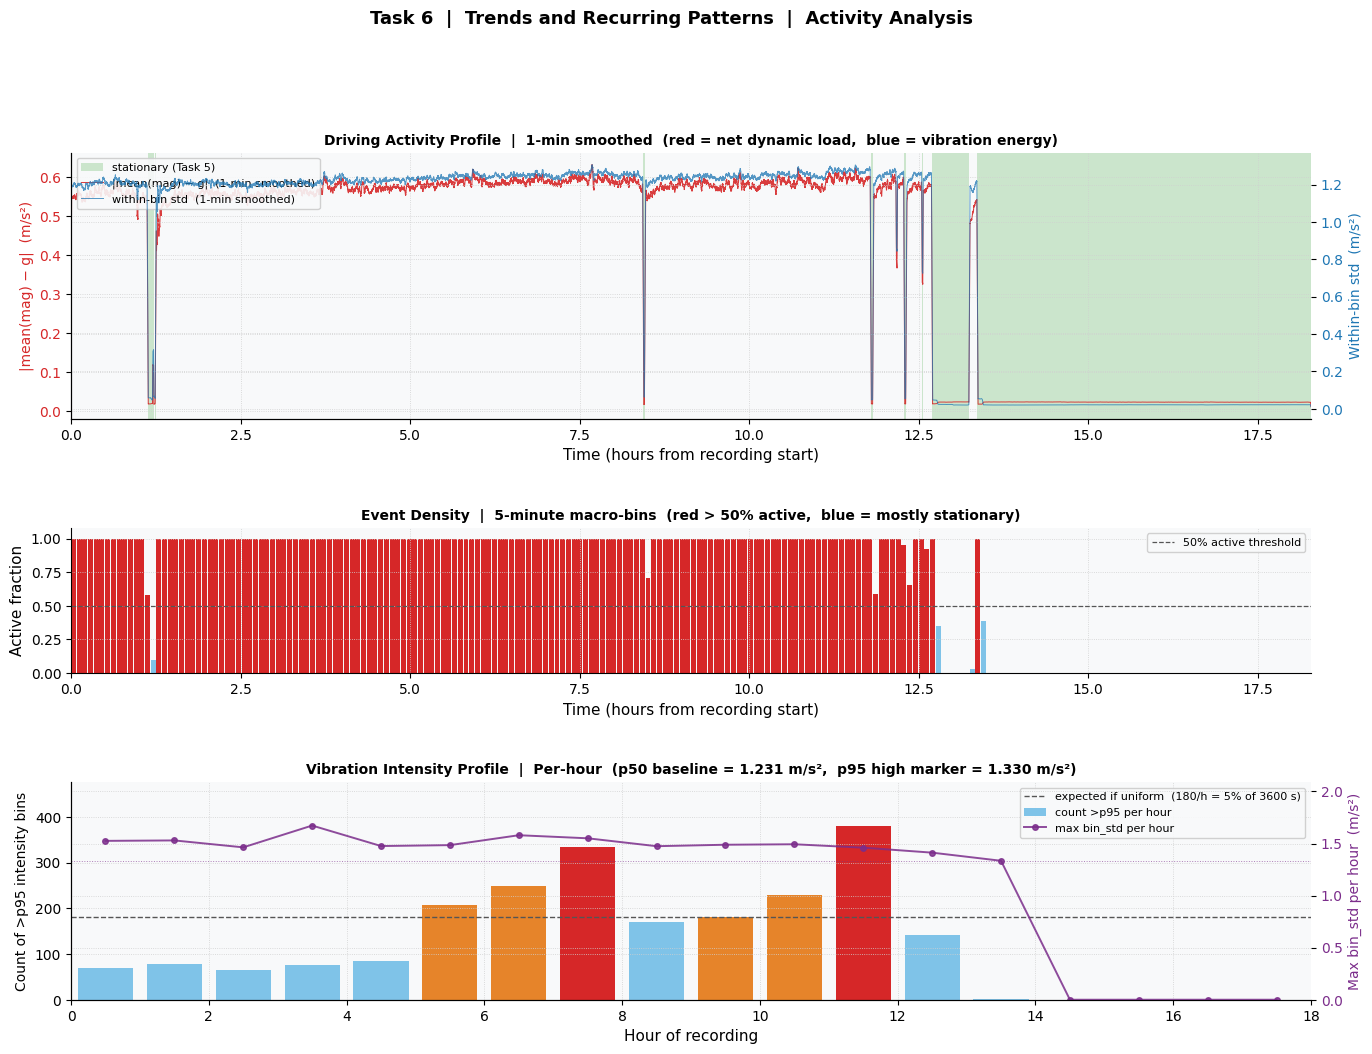

Saved: fig_trends_activity.png


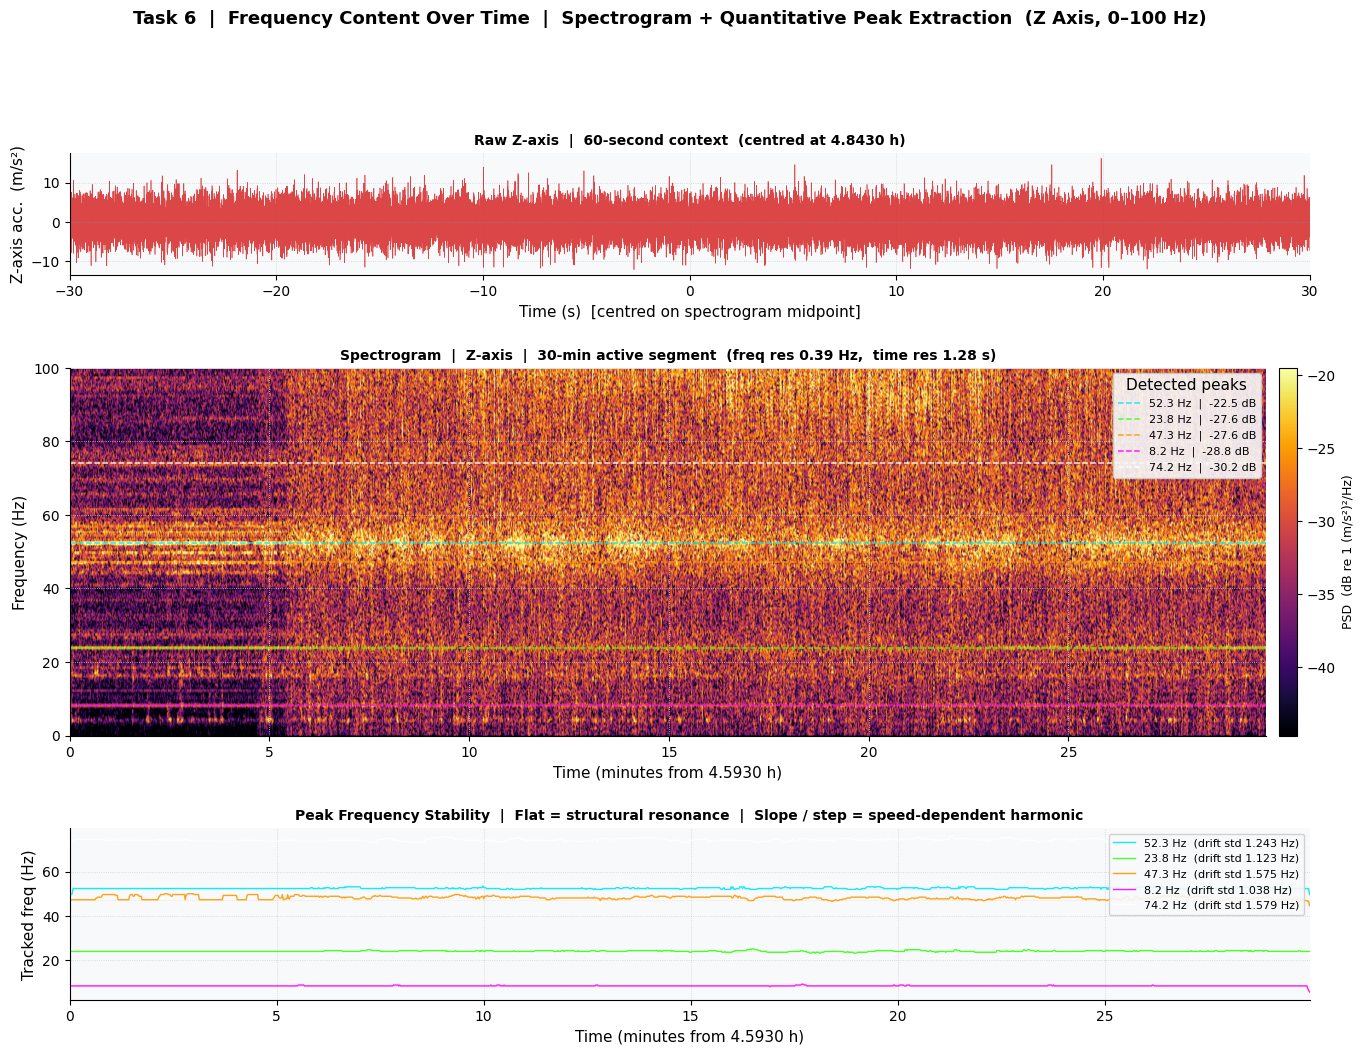

Saved: fig_trends_spectrogram.png


In [10]:
# ------------------------------------------------------------
# TASK 6  |  Trends and Recurring Patterns  (revised)
# ------------------------------------------------------------
# Goal
# ----
# Expose the temporal structure and recurring mechanical
# signatures of an 18-hour physical system recording across three
# complementary analyses.
#
# ── Analysis A  |  Operational Activity Timeline ──────────────────
# Reuses 1-second bin statistics from Task 5 (bin_mean, bin_std,
# stat_bins). Two channels are smoothed to 1-minute resolution:
#
#   mag_dev = |bin_mean − g|
#       Orientation-independent net dynamic load. Near zero at
#       rest; elevated during deceleration, acceleration, lateral motion.
#
#   bin_std  (from Task 5)
#       Within-bin oscillatory energy. Reflects operational surface
#       quality and structural vibration.
#
# A 5-minute macro-bin bar chart quantifies active fraction per
# window, making operation and rest phases legible at a glance.
#
# ── Analysis B  |  Vibration Intensity Profile ────────────────
# During active operation, the 1-second bin_std is consistently
# high (median ~1.23 m/s²). This tells us the physical system is under
# continuous broadband vibration — operational surface, motor, and
# mechanical damping system all contribute. Rather than apply absolute thresholds
# that would sweep in most active bins, we characterise HOW the
# intensity distribution shifts across the session:
#
#   Intensity baseline  : p50 of active bin_std (~1.23 m/s²)
#   High-intensity marker: p95 of active bin_std (~1.31 m/s²)
#
# Per-hour summary:
#   count_p95  — number of 1-second bins per hour exceeding the
#                session-wide 95th-percentile vibration level.
#                Uniform counts → consistent operation character.
#                Elevated hours → higher-vibration surface, higher speed, or
#                harder manoeuvring.
#   max_std    — maximum within-bin std that hour: captures the
#                single most intense second in each hour.
#
# ── Analysis C  |  Spectrogram + Quantitative Peak Extraction ─
# Short-time Fourier transform of Z-axis (most dynamic) over the
# longest active operation block (30-min clip). Two quantitative
# steps beyond the visual:
#
#   1. Time-averaged mean PSD → peak detection
#      Averaging across all ~1400 time slices suppresses transient
#      features, leaving only persistent resonances. scipy
#      find_peaks on the mean PSD returns frequency, power, and
#      prominence for each dominant mode.
#
#   2. Per-slice frequency tracking → stability classification
#      For each peak, the local argmax is tracked within ±3 Hz
#      across every time slice. Low std → structural resonance
#      (speed-independent). Drifting → rotation harmonic (wheel,
#      motor) whose frequency follows physical system speed.
#
# Figures
# -------
#   fig_trends_activity.png    Figure 7  (Analyses A + B)
#   fig_trends_spectrogram.png Figure 8  (Analysis C)
# ------------------------------------------------------------
from scipy import signal as sp_signal

# ------------------------------------------------------------
# ANALYSIS A  |  Operational Activity Timeline
# ------------------------------------------------------------
mag_dev_bins = np.abs(bin_mean - G_STANDARD)

# 60-second boxcar rolling mean
SMOOTH_BINS = 60
kernel = np.ones(SMOOTH_BINS) / SMOOTH_BINS
mag_dev_smooth = np.convolve(mag_dev_bins, kernel, mode='same')
bin_std_smooth  = np.convolve(bin_std,      kernel, mode='same')

# 5-minute macro-bins: fraction of active bins per window
MACRO_SEC   = 5 * 60
MACRO_BINS  = int(MACRO_SEC / BIN_SEC)
n_macro     = n_bins // MACRO_BINS
n_use_m     = n_macro * MACRO_BINS
stat_bins_m = stat_bins[:n_use_m].reshape(n_macro, MACRO_BINS)
active_frac = 1.0 - stat_bins_m.mean(axis=1)
t_macro_h   = np.linspace(0, duration / 3600, n_macro)

print('Analysis A — Activity Timeline')
print(f'  Smooth window          : {SMOOTH_BINS} s')
print(f'  Macro-bin width        : {MACRO_SEC:.0f} s  ({MACRO_SEC/60:.0f} min)')
print(f'  Number of macro-bins   : {n_macro}')
print(f'  Active fraction range  : {active_frac.min():.3f} – {active_frac.max():.3f}')

# ------------------------------------------------------------
# ANALYSIS B  |  Vibration Intensity Profile
# ------------------------------------------------------------
# Why NOT raw per-sample thresholds:
# -----------------------------------
# At 800 Hz the instantaneous magnitude fluctuates due to sensor
# noise and surface micro-texture. The per-bin max (max of 800 samples)
# will exceed any physically-motivated g-threshold in nearly every
# active bin — it measures noise spread, not physical system dynamics.
#
# Why NOT a fixed absolute std threshold:
# ----------------------------------------
# The within-1-second std for active bins is very tightly
# concentrated: p50 = 1.23 m/s², p99 = 1.38 m/s². A fixed
# threshold like 0.5 m/s² would catch almost nothing; 1.0 m/s²
# would catch almost everything. There is no clean gap in the
# active-bin std distribution that a threshold could exploit.
#
# Correct approach — session-relative intensity analysis:
# --------------------------------------------------------
# We characterise the DISTRIBUTION of vibration intensity across
# time rather than labelling individual bins as "events".
#
#   Baseline (p50) : median active bin_std — the typical 1-second
#                    vibration level during this drive session.
#   High marker (p95): bins in the top 5% of the session's active
#                    distribution — genuinely elevated relative to
#                    what this physical system/route normally experiences.
#
# Aggregating by hour gives 18 bars that show whether any operation
# phase was materially more intense than the session average.
# The max_std line captures the single worst second per hour
# (the hardest individual event) without inflating counts.

active_mask  = ~stat_bins
n_active     = int(active_mask.sum())
active_h     = n_active * BIN_SEC / 3600

# Session-wide intensity percentiles for active bins
P50_STD = float(np.percentile(bin_std[active_mask], 50))   # baseline
P95_STD = float(np.percentile(bin_std[active_mask], 95))   # high-intensity marker
P99_STD = float(np.percentile(bin_std[active_mask], 99))   # extreme marker

# Per-hour aggregation
HOUR_BINS = int(3600 / BIN_SEC)    # 3600 bins per hour
n_hours   = n_bins // HOUR_BINS
n_use_hr  = n_hours * HOUR_BINS

std_h     = bin_std[:n_use_hr].reshape(n_hours, HOUR_BINS)
active_h2 = active_mask[:n_use_hr].reshape(n_hours, HOUR_BINS)

# Count of high-intensity (>p95) seconds per hour (active only)
count_p95 = ((std_h >= P95_STD) & active_h2).sum(axis=1).astype(float)
count_p99 = ((std_h >= P99_STD) & active_h2).sum(axis=1).astype(float)

# Max bin_std per hour (worst single second); 0 for fully stationary hours
max_std_hr = np.where(
    active_h2.any(axis=1),
    np.where(active_h2, std_h, 0.0).max(axis=1),
    0.0,
)

t_hours_h = np.arange(n_hours)   # integer hour labels

print(f'\nAnalysis B — Vibration Intensity Profile')
print(f'  Active bins            : {n_active:,}  ({active_h:.2f} h)')
print(f'  Baseline   (p50 std)   : {P50_STD:.4f} m/s²  (typical active 1-s vibration)')
print(f'  High mark  (p95 std)   : {P95_STD:.4f} m/s²  (top 5% of session)')
print(f'  Extreme    (p99 std)   : {P99_STD:.4f} m/s²  (top 1% of session)')
print(f'  Expected p95 count/h   : {0.05 * HOUR_BINS:.0f}  (if uniform)')
print(f'\n  Per-hour p95 counts:')
for h in range(n_hours):
    active_secs = int(active_h2[h].sum())
    if active_secs > 0:
        print(f'    Hour {h:>2}:  p95={int(count_p95[h]):>4} bins  '
              f'p99={int(count_p99[h]):>3} bins  '
              f'max_std={max_std_hr[h]:.4f} m/s²  '
              f'({active_secs} active s)')

# ------------------------------------------------------------
# ANALYSIS C  |  Spectrogram + Peak Extraction
# ------------------------------------------------------------

# Identify longest continuous active window
segs_by_start = sorted(segments, key=lambda x: x['start_s'])
candidate_windows = []
if segs_by_start:
    candidate_windows.append((0.0, segs_by_start[0]['start_s']))
for i in range(len(segs_by_start) - 1):
    candidate_windows.append((segs_by_start[i]['end_s'],
                               segs_by_start[i + 1]['start_s']))
if segs_by_start:
    candidate_windows.append((segs_by_start[-1]['end_s'], duration))

MIN_ACTIVE_S  = 10 * 60
active_windows = sorted(
    [(s, e) for s, e in candidate_windows if (e - s) >= MIN_ACTIVE_S],
    key=lambda x: x[1] - x[0], reverse=True,
)

SPECT_SEC = 30 * 60
do_spectrogram = False

if active_windows:
    win_s, win_e = active_windows[0]
    win_dur_s    = win_e - win_s
    centre_s     = 0.5 * (win_s + win_e)
    clip_s       = max(win_s, centre_s - SPECT_SEC / 2)
    clip_e       = min(win_e, clip_s + SPECT_SEC)
    clip_s       = max(win_s, clip_e - SPECT_SEC)

    idx_s = int(clip_s * eff_hz)
    idx_e = int(clip_e * eff_hz)
    z_seg = df['acc_z'].values[idx_s:idx_e].astype(np.float64)

    SPECT_NPERSEG  = 2048
    SPECT_NOVERLAP = SPECT_NPERSEG // 2
    SPECT_FMAX     = 100.0

    freqs, times, Sxx = sp_signal.spectrogram(
        z_seg, fs=eff_hz,
        window='hann', nperseg=SPECT_NPERSEG, noverlap=SPECT_NOVERLAP,
        detrend='constant', scaling='density',
    )
    Sxx_db     = 10.0 * np.log10(np.maximum(Sxx, 1e-12))
    f_mask     = freqs <= SPECT_FMAX
    freqs_trim = freqs[f_mask]
    Sxx_trim   = Sxx_db[f_mask, :]
    freq_res   = eff_hz / SPECT_NPERSEG
    time_res   = (SPECT_NPERSEG - SPECT_NOVERLAP) / eff_hz
    times_min  = (times - times[0]) / 60.0

    # ── Peak extraction: time-averaged mean PSD ───────────────
    # Averaging across all time slices suppresses transient events,
    # retaining only persistently present resonances.
    mean_psd_db = Sxx_trim.mean(axis=1)

    peak_idx, peak_props = sp_signal.find_peaks(
        mean_psd_db,
        height=np.percentile(mean_psd_db, 55),
        prominence=1.5,
        distance=int(3.0 / freq_res),
    )
    peak_freqs  = freqs_trim[peak_idx]
    peak_powers = mean_psd_db[peak_idx]

    TOP_N      = min(5, len(peak_idx))
    top_order  = np.argsort(peak_powers)[::-1][:TOP_N]
    top_freqs  = peak_freqs[top_order]
    top_powers = peak_powers[top_order]

    # ── Per-slice frequency tracking ─────────────────────────
    # Track the local dominant frequency within ±TRACK_BW Hz of
    # each detected peak across every time slice.
    # Low std → structural resonance (frequency-stable, independent
    #           of physical system speed or motor RPM).
    # High std or visible drift → rotation harmonic that shifts
    #           as speed/RPM changes.
    TRACK_BW    = 3.0
    freq_tracks = []
    for tf in top_freqs:
        band      = (freqs_trim >= tf - TRACK_BW) & (freqs_trim <= tf + TRACK_BW)
        band_freq = freqs_trim[band]
        local_idx = Sxx_trim[band, :].argmax(axis=0)
        freq_tracks.append(band_freq[local_idx])

    INTERP_RULES = [
        (0,  5,  'mechanical damping system / body motion'),
        (5,  15, 'drive component rotation / drivetrain'),
        (15, 40, 'motor harmonic / operational surface'),
        (40, 100,'structural / chassis resonance'),
    ]

    print(f'\nAnalysis C — Spectrogram + Peak Extraction')
    print(f'  Longest active window  : {win_dur_s / 3600:.3f} h  '
          f'[{win_s/3600:.4f} – {win_e/3600:.4f} h]')
    print(f'  Clip                   : {clip_s/3600:.4f} – {clip_e/3600:.4f} h  '
          f'({len(z_seg):,} samples)')
    print(f'  STFT shape             : {Sxx_trim.shape}')
    print(f'  Freq res {freq_res:.3f} Hz  |  Time res {time_res:.3f} s')
    print(f'\n  Top {TOP_N} persistent peaks in mean PSD:')
    print(f'  {"#":>3}  {"Freq":>8}  {"Power":>9}  {"Prom":>7}  '
          f'{"Drift std":>10}  Stability       Interpretation')
    print(f'  {"":=<85}')
    for i, (tf, tp) in enumerate(zip(top_freqs, top_powers)):
        prom  = float(peak_props['prominences'][top_order[i]])
        drift = float(freq_tracks[i].std()) if i < len(freq_tracks) else float('nan')
        kind  = next(lbl for lo, hi, lbl in INTERP_RULES if lo <= tf < hi)
        stab  = 'stable (structural)' if drift < 1.0 else 'drifting (speed-dep.)'
        print(f'  {i+1:>3}  {tf:>7.2f}  {tp:>8.2f}  {prom:>7.2f}  '
              f'{drift:>10.4f}  {stab:<20}  {kind}')

    do_spectrogram = True
else:
    print('\nNo active window ≥ 10 min found; skipping spectrogram.')

# ------------------------------------------------------------
# FIGURE 7  |  Activity Timeline + Vibration Intensity Profile
# ------------------------------------------------------------

fig7, axes7 = plt.subplots(
    3, 1, figsize=(16, 11),
    gridspec_kw={'height_ratios': [2.2, 1.2, 1.8], 'hspace': 0.52},
)

# ── Panel 1: smoothed activity channels ──────────────────────
ax1  = axes7[0]
ax1r = ax1.twinx()

for i, sg in enumerate(segs_by_start):
    lbl = 'stationary (Task 5)' if i == 0 else '_nolegend_'
    ax1.axvspan(sg['start_s'] / 3600, sg['end_s'] / 3600,
                color='#2ca02c', alpha=0.22, linewidth=0, label=lbl)

ax1.plot(t_bins_h, mag_dev_smooth, color='#d62728', linewidth=0.7, alpha=0.9,
         label='|mean(mag) − g|  (1-min smoothed)')
ax1r.plot(t_bins_h, bin_std_smooth, color='#1f77b4', linewidth=0.7, alpha=0.75,
          label='within-bin std  (1-min smoothed)')

ax1.set_xlim(0, duration / 3600)
ax1.set_xlabel('Time (hours from recording start)')
ax1.set_ylabel('|mean(mag) − g|  (m/s²)', color='#d62728', fontsize=10)
ax1r.set_ylabel('Within-bin std  (m/s²)', color='#1f77b4', fontsize=10)
ax1.tick_params(axis='y', labelcolor='#d62728')
ax1r.tick_params(axis='y', labelcolor='#1f77b4')
ax1.set_title('Operational Activity Profile  |  1-min smoothed  '
              '(red = net dynamic load,  blue = vibration energy)',
              fontsize=10, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1r.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc='upper left', framealpha=0.9)

# ── Panel 2: 5-min macro-bin active fraction ─────────────────
ax2 = axes7[1]
bar_colors = ['#d62728' if f > 0.5 else '#7fc3e8' for f in active_frac]
ax2.bar(t_macro_h, active_frac, width=(MACRO_SEC / 3600) * 0.88, align='edge',
        color=bar_colors, linewidth=0)
ax2.axhline(0.5, color='#555555', linewidth=0.9, linestyle='--',
            label='50% active threshold')
ax2.set_xlim(0, duration / 3600)
ax2.set_ylim(0, 1.08)
ax2.set_xlabel('Time (hours from recording start)')
ax2.set_ylabel('Active fraction')
ax2.set_title('Event Density  |  5-minute macro-bins  '
              '(red > 50% active,  blue = mostly stationary)',
              fontsize=10, fontweight='bold')
ax2.legend(fontsize=8)

# ── Panel 3: Per-hour vibration intensity profile ────────────
# Left axis : count of high-intensity (>p95) seconds per hour
# Right axis: max within-bin std per hour
ax3  = axes7[2]
ax3r = ax3.twinx()

# Expected count if intensity were uniform (5% of HOUR_BINS per active hour)
expected_p95 = 0.05 * HOUR_BINS

bar_c = ['#d62728' if count_p95[h] > expected_p95 * 1.5 else
         '#e6842a' if count_p95[h] > expected_p95 else
         '#7fc3e8' for h in range(n_hours)]

ax3.bar(t_hours_h + 0.5, count_p95, width=0.80, color=bar_c, linewidth=0,
        label='count >p95 per hour')
ax3.axhline(expected_p95, color='#555555', linewidth=1.0, linestyle='--',
            label=f'expected if uniform  ({expected_p95:.0f}/h = 5% of 3600 s)')

ax3r.plot(t_hours_h + 0.5, max_std_hr, color='#7b2d8b', linewidth=1.4,
          marker='o', markersize=4, alpha=0.85, label='max bin_std per hour')
ax3r.axhline(P95_STD, color='#7b2d8b', linewidth=0.7, linestyle=':', alpha=0.6)

ax3.set_xlim(0, n_hours)
ax3.set_ylim(0, count_p95.max() * 1.25)
ax3r.set_ylim(0, max_std_hr.max() * 1.25)
ax3.set_xlabel('Hour of recording')
ax3.set_ylabel('Count of >p95 intensity bins', fontsize=10)
ax3r.set_ylabel('Max bin_std per hour  (m/s²)', color='#7b2d8b', fontsize=10)
ax3r.tick_params(axis='y', labelcolor='#7b2d8b')
ax3.set_title(
    f'Vibration Intensity Profile  |  Per-hour  '
    f'(p50 baseline = {P50_STD:.3f} m/s²,  p95 high marker = {P95_STD:.3f} m/s²)',
    fontsize=10, fontweight='bold',
)
h3, l3 = ax3.get_legend_handles_labels()
h3r, l3r = ax3r.get_legend_handles_labels()
ax3.legend(h3 + h3r, l3 + l3r, fontsize=8, loc='upper right', framealpha=0.9)

fig7.suptitle('Task 6  |  Trends and Recurring Patterns  |  Activity Analysis',
              fontsize=13, fontweight='bold', y=1.01)

plt.savefig('fig_trends_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_trends_activity.png')

# ------------------------------------------------------------
# FIGURE 8  |  Spectrogram + Quantitative Peak Extraction
# ------------------------------------------------------------

if do_spectrogram:
    PEAK_COLORS = ['#00e5ff', '#39ff14', '#ff9800', '#ff00ff', '#ffffff']

    fig8, (ax8t, ax8s, ax8p) = plt.subplots(
        3, 1, figsize=(16, 11),
        gridspec_kw={'height_ratios': [1, 3, 1.4], 'hspace': 0.42},
    )

    # ── Top: 60-second raw Z-axis context ─────────────────────
    CTX_SEC  = 60
    ctx_mid  = len(z_seg) // 2
    ctx_half = int(CTX_SEC / 2 * eff_hz)
    ctx_lo   = max(0, ctx_mid - ctx_half)
    ctx_hi   = min(len(z_seg), ctx_mid + ctx_half)
    t_ctx    = (np.arange(ctx_hi - ctx_lo) / eff_hz) - CTX_SEC / 2

    ax8t.plot(t_ctx, z_seg[ctx_lo:ctx_hi], color='#d62728', linewidth=0.45, alpha=0.85)
    ax8t.axhline(0, color='#888888', linewidth=0.6, linestyle=':')
    ax8t.set_xlim(-CTX_SEC / 2, CTX_SEC / 2)
    ax8t.set_xlabel('Time (s)  [centred on spectrogram midpoint]')
    ax8t.set_ylabel('Z-axis acc.  (m/s²)')
    ax8t.set_title(
        f'Raw Z-axis  |  60-second context  '
        f'(centred at {(clip_s + (clip_e - clip_s) / 2) / 3600:.4f} h)',
        fontsize=10, fontweight='bold',
    )

    # ── Middle: spectrogram annotated with peak lines ─────────
    im = ax8s.pcolormesh(
        times_min, freqs_trim, Sxx_trim,
        shading='gouraud', cmap='inferno',
        vmin=np.percentile(Sxx_trim, 5),
        vmax=np.percentile(Sxx_trim, 99),
    )
    cbar = fig8.colorbar(im, ax=ax8s, pad=0.01, fraction=0.025)
    cbar.set_label('PSD  (dB re 1 (m/s²)²/Hz)', fontsize=9)

    for i, (tf, tp) in enumerate(zip(top_freqs, top_powers)):
        c = PEAK_COLORS[i % len(PEAK_COLORS)]
        ax8s.axhline(tf, color=c, linewidth=1.1, linestyle='--', alpha=0.85,
                     label=f'{tf:.1f} Hz  |  {tp:.1f} dB')

    ax8s.set_ylim(0, SPECT_FMAX)
    ax8s.set_xlabel(f'Time (minutes from {clip_s / 3600:.4f} h)')
    ax8s.set_ylabel('Frequency (Hz)')
    ax8s.set_title(
        f'Spectrogram  |  Z-axis  |  {SPECT_SEC/60:.0f}-min active segment  '
        f'(freq res {freq_res:.2f} Hz,  time res {time_res:.2f} s)',
        fontsize=10, fontweight='bold',
    )
    ax8s.legend(fontsize=8, loc='upper right', title='Detected peaks', framealpha=0.9)

    # ── Bottom: peak frequency stability over time ────────────
    # 21-point median filter smooths argmax noise.
    # A flat trace → structural resonance unaffected by speed.
    # A visible slope or step → harmonic tracking physical system RPM/speed.
    for i, (tf, track) in enumerate(zip(top_freqs, freq_tracks)):
        c     = PEAK_COLORS[i % len(PEAK_COLORS)]
        drift = float(track.std())
        smooth = sp_signal.medfilt(track.astype(float), kernel_size=21)
        ax8p.plot(times_min, smooth, color=c, linewidth=1.0, alpha=0.9,
                  label=f'{tf:.1f} Hz  (drift std {drift:.3f} Hz)')
        ax8p.axhline(tf, color=c, linewidth=0.5, linestyle=':', alpha=0.35)

    ax8p.set_xlim(0, times_min[-1])
    ax8p.set_xlabel(f'Time (minutes from {clip_s / 3600:.4f} h)')
    ax8p.set_ylabel('Tracked freq (Hz)')
    ax8p.set_title(
        'Peak Frequency Stability  |  '
        'Flat = structural resonance  |  Slope / step = speed-dependent harmonic',
        fontsize=10, fontweight='bold',
    )
    ax8p.legend(fontsize=8, loc='upper right', framealpha=0.9)

    fig8.suptitle(
        'Task 6  |  Frequency Content Over Time  |  '
        'Spectrogram + Quantitative Peak Extraction  (Z Axis, 0–100 Hz)',
        fontsize=13, fontweight='bold', y=1.01,
    )

    plt.savefig('fig_trends_spectrogram.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: fig_trends_spectrogram.png')
